# 08 — การตรวจลูกเห็บด้วย SHI, MESH และ pyhail
## Hail Detection Using a Remote Observed Sounding Proxy, SHI, MESH and pyhail

**กรณีศึกษา**

- Radar site: **Omkoi**
- Agency: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- Event: **observed hail event**
- Date: **18 March 2023**
- Peak radar volume: อ่านจาก Notebook 03/07
- Hail toolkit: **pyhail 3.4.2**
- Default environmental input: **Dien Bien Phu, Vietnam (WMO 48811), 00 UTC sounding used as a remote observed proxy**
- Figure text: **English only**
- Teaching explanation: **ภาษาไทย**

---

## สิ่งที่เปลี่ยนจาก Notebook 08 รุ่นเดิม

รุ่นนี้ไม่ใช้ simulated thermal levels เป็นค่าเริ่มต้นอีกต่อไป

Default workflow คือ:

```text
Observed upper-air sounding
Dien Bien Phu, Vietnam
WMO 48811
18 March 2023, nominal 00 UTC
        ↓
Sounding QC
        ↓
Interpolate 0 / −10 / −20 / −30°C levels
        ↓
Quantify spatial + temporal representativeness
        ↓
Use 0°C and −20°C levels as pyhail thermal inputs
        ↓
SHI / MESH / POSH
        ↓
Thermal-level sensitivity ±500 m
```

> **ข้อจำกัดสำคัญ**
>
> Dien Bien Phu sounding เป็น observation จริง แต่ไม่ได้อยู่เหนือ Omkoi storm โดยตรง  
> จึงเรียกว่า **remote observed sounding proxy** ไม่ใช่ local storm sounding

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 08 ผู้เรียนควรสามารถ:

1. อ่าน upper-air sounding CSV จาก GitHub
2. ตรวจ station metadata และ profile time
3. ตรวจ temperature–height profile
4. interpolate ระดับ 0, −10, −20 และ −30°C
5. อธิบายเหตุผลที่ MESH ต้องใช้ environmental thermal levels
6. คำนวณระยะจาก sounding station ถึง radar
7. คำนวณระยะจาก sounding station ถึง storm reference point
8. คำนวณ temporal offset ระหว่าง sounding และ radar event
9. อธิบาย spatial/temporal representativeness
10. แยก `PROXY_SOUNDING`, `SIMULATED` และ `MANUAL` thermal modes
11. ใช้ 0°C และ −20°C levels เป็น SHI/MESH inputs
12. อธิบาย Severe Hail Index
13. อธิบาย hail kinetic-energy weighting
14. คำนวณ SHI ด้วย pyhail
15. คำนวณ MESH หลาย formulations
16. เปรียบเทียบ Witt, MH75, MH95 และ blend
17. คำนวณ POSH ใน pyhail framework
18. ทำ proxy-thermal sensitivity ±500 m
19. export SHI/MESH/POSH เป็น GeoTIFF
20. ทำ optional 10-volume MESH lifecycle
21. ตรวจ dual-pol readiness สำหรับ HDR/HSDA/HACC
22. อธิบายว่าทำไม HSDA ยังไม่ควรถูกบังคับใช้กับ dataset นี้
23. export provenance และ uncertainty metadata
24. แยก algorithm output ออกจาก observed hail truth

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**RESEARCH NOTE** — ประเด็นที่ต้องระบุใน manuscript

# 1. SHI และ MESH ต้องใช้ทั้ง radar และ environment

Reflectivity สูงเพียงอย่างเดียวไม่เพียงพอสำหรับ SHI

แนวคิดพื้นฐาน:

```text
Reflectivity intensity
        +
Height relative to 0°C and −20°C
        ↓
Hail kinetic-energy weighting
        ↓
SHI
        ↓
MESH
```

SHI ใช้ reflectivity weighting และ temperature-height weighting

ตัวอย่าง temperature weighting:

$$
W_T
=
\frac{
H-H_{0^\circ C}
}{
H_{-20^\circ C}-H_{0^\circ C}
}
$$

โดยกำหนดโดยแนวคิดว่า:

```text
below 0°C level      → little / no SHI contribution
between 0 and −20°C → increasing contribution
above −20°C level    → full thermal weighting
```

# 2. MESH formulations

pyhail 3.4.2 รองรับ formulations หลัก:

```text
witt1998
mh2019_75
mh2019_95
blend
```

ตัวอย่างสมการ Witt:

$$
MESH
=
2.54
SHI^{0.5}
$$

Murillo–Homeyer formulations ถูก recalibrate จาก hail-report dataset ที่ใหญ่กว่า

ดังนั้นค่าจากแต่ละ formulation สามารถต่างกันมากได้

> **สำคัญ**
>
> `MESH = 40 mm` หมายถึง radar-derived hail-size estimate ตาม algorithm  
> ไม่ได้หมายความว่ามีการวัด hailstone 40 mm ที่พื้น

# 3. ทำไมใช้ Dien Bien Phu sounding ได้ แต่ต้องเรียกว่า proxy

สำหรับเหตุการณ์นี้ไม่มี local upper-air sounding ของไทยตรงเวลาที่ต้องการ

เราจึงใช้:

```text
Station: Dien Bien Phu, Vietnam
WMO:     48811
Lat:     21.370°N
Lon:     103.000°E
Nominal: 00 UTC 18 March 2023
```

ข้อดี:

- เป็น observation จริง
- มี vertical profile ถึง upper troposphere
- มี temperature / dew point / wind ครบ
- สามารถ derive 0 ถึง −30°C levels ได้

ข้อจำกัด:

- อยู่ห่างจาก Omkoi radar หลายร้อยกิโลเมตร
- อยู่ห่างจาก storm reference point หลายร้อยกิโลเมตร
- sounding ก่อน radar peak หลายชั่วโมง

ดังนั้น Notebook จะคำนวณ representativeness diagnostics อัตโนมัติและเก็บลง metadata

# 4. Thermal input modes

แก้ค่าเพียงบรรทัดเดียว:

```python
THERMAL_INPUT_MODE = "PROXY_SOUNDING"
```

ตัวเลือก:

```text
"PROXY_SOUNDING"
    ใช้ observed sounding 48811 เป็น remote proxy

"SIMULATED"
    ใช้ illustrative teaching values เท่านั้น
    ผลต้องติดป้าย SIMULATED

"MANUAL"
    ผู้สอนใส่ค่าจาก sounding / ERA5 / NWP ที่มีแหล่งที่มาชัดเจน
```

Default คือ:

```text
PROXY_SOUNDING
```

และจะทำ ±500 m thermal sensitivity เพิ่มเพื่อประเมิน uncertainty

# 5. ติดตั้งไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "pyhail==3.4.2",
    "numpy>=1.26",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "scipy>=1.12",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing/checking Notebook 08 packages ...")
subprocess.check_call(cmd)
print("Package installation complete.")

Installing/checking Notebook 08 packages ...
Package installation complete.


# 6. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "google.colab not found — using current directory:"
    )
    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 7. นำเข้าไลบรารี

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import ast
import copy
import gc
import gzip
import inspect
import json
import math
import shutil
import sys
import tempfile
import time
import urllib.request
import warnings

from pathlib import Path
from urllib.parse import quote

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import pyart
import pyhail

from pyhail import (
    mesh_grid,
    mesh_ppi,
    hdr,
    hsda,
    hacc,
)

from netCDF4 import num2date

import rasterio
from rasterio.transform import from_origin

from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "pyhail": getattr(
        pyhail,
        "__version__",
        "unknown",
    ),
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,pyhail,unknown
6,rasterio,1.5.1


In [4]:
# CELL 4 — Publication-quality plotting standard

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )


def resolve_reflectivity_colormap():
    for candidate in [
        "NWSRef",
        "HomeyerRainbow",
        "Carbone11",
        "turbo",
    ]:
        if candidate in matplotlib.colormaps:
            return candidate

    return "viridis"


ZH_CMAP = resolve_reflectivity_colormap()

print(
    "Reflectivity colormap:",
    ZH_CMAP,
)

Reflectivity colormap: NWSRef


# 8. อ่าน course configuration และ readiness

Notebook 08 ใช้ผลจาก:

```text
Notebook 03 → storm-focused 3-D grid
Notebook 07 → severe-core metrics and lifecycle
```

ดังนั้นจะตรวจ:

```text
03_readiness_check.csv
07_readiness_check.csv
03_grid_configuration.csv
07_severe_storm_lifecycle_metrics.csv
```

In [5]:
# CELL 5 — Load course configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "course_config.json not found — run Notebook 01 first."
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event is not marked as observed_hail."
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

Active event: 20230318_observed_hail_1106_1200


In [6]:
# CELL 6 — Paths and readiness

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_NETCDF_DIR = (
    EVENT_ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "08"
)

METADATA_DIR = (
    EVENT_ROOT
    / "02_metadata"
)

SOUNDING_SOURCE_DIR = (
    EVENT_ROOT
    / "00_source_github"
    / "sounding"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    FIGURE_DIR,
    METADATA_DIR,
    SOUNDING_SOURCE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

READINESS_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

LIFECYCLE_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_severe_storm_lifecycle_metrics.csv"
)

for required_file in [
    READINESS_03_CSV,
    READINESS_07_CSV,
    GRID_CONFIG_03_CSV,
    LIFECYCLE_07_CSV,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_file}"
        )


readiness_03 = pd.read_csv(
    READINESS_03_CSV
)

readiness_07 = pd.read_csv(
    READINESS_07_CSV
)

if not (
    readiness_03[
        "status"
    ]
    == "PASS"
).all():
    raise RuntimeError(
        "Notebook 03 readiness did not fully pass."
    )

if not (
    readiness_07[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_07
    )
    raise RuntimeError(
        "Notebook 07 readiness did not fully pass."
    )


grid_config_03 = pd.read_csv(
    GRID_CONFIG_03_CSV
)

grid_config_lookup = dict(
    zip(
        grid_config_03[
            "parameter"
        ],
        grid_config_03[
            "value"
        ],
    )
)

LIFECYCLE_07 = pd.read_csv(
    LIFECYCLE_07_CSV
)

print(
    "Notebook 03 readiness: PASS"
)

print(
    "Notebook 07 readiness: PASS"
)

Notebook 03 readiness: PASS
Notebook 07 readiness: PASS


# 9. Thermal input switch

สำหรับชั้นเรียนนี้ default เป็น remote observed sounding proxy

```python
THERMAL_INPUT_MODE = "PROXY_SOUNDING"
```

หากต้องการสอน simulation:

```python
THERMAL_INPUT_MODE = "SIMULATED"
```

หากมีค่าจาก ERA5 / NWP / local sounding ที่เตรียมเอง:

```python
THERMAL_INPUT_MODE = "MANUAL"
```

ทุก mode จะถูกบันทึกลง metadata และชื่อ output เพื่อป้องกันการสับสน

In [7]:
# CELL 7 — Thermal-input and hail-analysis parameters

THERMAL_INPUT_MODE = "PROXY_SOUNDING"

ALLOWED_THERMAL_MODES = {
    "PROXY_SOUNDING",
    "SIMULATED",
    "MANUAL",
}

if THERMAL_INPUT_MODE not in (
    ALLOWED_THERMAL_MODES
):
    raise ValueError(
        f"THERMAL_INPUT_MODE must be one of {ALLOWED_THERMAL_MODES}"
    )


# ------------------------------------------------------------
# Proxy sounding
# ------------------------------------------------------------

GITHUB_OWNER = "nattaponm"

GITHUB_REPO = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

GITHUB_BRANCH = "main"

PROXY_SOUNDING_FILENAME = (
    "2023031800-48811_sounding_Vietnam.csv"
)

PROXY_STATION_NAME = (
    "Dien Bien Phu"
)

PROXY_STATION_WMO = "48811"

PROXY_NOMINAL_TIME_UTC = pd.Timestamp(
    "2023-03-18 00:00:00",
    tz="UTC",
)


# ------------------------------------------------------------
# Simulation fallback — TEACHING ONLY
# ------------------------------------------------------------

SIMULATED_FREEZING_LEVEL_M_MSL = 5000.0

SIMULATED_MINUS10_LEVEL_M_MSL = 6500.0

SIMULATED_MINUS20_LEVEL_M_MSL = 8000.0

SIMULATED_MINUS30_LEVEL_M_MSL = 9500.0


# ------------------------------------------------------------
# Manual documented input
# ------------------------------------------------------------

MANUAL_FREEZING_LEVEL_M_MSL = None

MANUAL_MINUS10_LEVEL_M_MSL = None

MANUAL_MINUS20_LEVEL_M_MSL = None

MANUAL_MINUS30_LEVEL_M_MSL = None

MANUAL_THERMAL_SOURCE = None


# ------------------------------------------------------------
# Sensitivity
# ------------------------------------------------------------

RUN_THERMAL_LEVEL_SENSITIVITY = True

THERMAL_PERTURBATION_M = 500.0


# ------------------------------------------------------------
# pyhail
# ------------------------------------------------------------

MESH_METHODS = [
    "witt1998",
    "mh2019_75",
    "mh2019_95",
    "blend",
]

PRIMARY_MESH_METHOD = "blend"

PYHAIL_SPECKLE_FILTER = True

PYHAIL_NEAR_RADAR_MASK_M = 10000.0

PYHAIL_TRANSITION_WIDTH = 200.0

RUN_OPTIONAL_MESH_LIFECYCLE = True

MESH_EXCEEDANCE_THRESHOLDS_MM = [
    10.0,
    20.0,
    25.0,
    40.0,
    50.0,
    75.0,
]

GEOTIFF_NODATA = -9999.0

print(
    "Thermal input mode:",
    THERMAL_INPUT_MODE,
)

print(
    "Primary MESH method:",
    PRIMARY_MESH_METHOD,
)

Thermal input mode: PROXY_SOUNDING
Primary MESH method: blend


In [8]:
# CELL 8 — Radar / grid parameters inherited from Notebook 03

FIELD_Z = str(
    grid_config_lookup[
        "field"
    ]
)

SELECTED_FILENAME = str(
    grid_config_lookup[
        "source_file"
    ]
)

RADAR_LAT = float(
    grid_config_lookup[
        "radar_latitude_deg"
    ]
)

RADAR_LON = float(
    grid_config_lookup[
        "radar_longitude_deg"
    ]
)

RADAR_ALTITUDE_M_MSL = float(
    grid_config_lookup[
        "radar_altitude_m_MSL"
    ]
)

TARGET_AZIMUTH_DEG = float(
    grid_config_lookup[
        "strong_echo_reference_azimuth_deg"
    ]
)

CORE_REFERENCE_RANGE_KM = float(
    grid_config_lookup[
        "strong_echo_reference_range_km"
    ]
)

RADAR_BAND = "S"

print(
    "Radar:",
    f"{RADAR_LAT:.6f}, {RADAR_LON:.6f}",
)

print(
    "Storm reference:",
    f"{TARGET_AZIMUTH_DEG:.2f}° / {CORE_REFERENCE_RANGE_KM:.2f} km",
)

Radar: 17.798207, 98.432326
Storm reference: 74.37° / 96.77 km


# 10. ตรวจ pyhail API ที่ติดตั้งจริง

Notebook pin `pyhail==3.4.2` แต่ยังตรวจ runtime signature เพื่อให้ code อ่านง่ายและ robust

โดยเฉพาะ:

```text
mesh_grid.main
mesh_ppi
HDR
HSDA
HACC
```

In [9]:
# CELL 9 — pyhail API inventory

api_rows = []

objects_to_check = {
    "mesh_grid.main": getattr(
        mesh_grid,
        "main",
        None,
    ),
    "mesh_ppi.pyart": getattr(
        mesh_ppi,
        "pyart",
        None,
    ),
    "mesh_ppi.main": getattr(
        mesh_ppi,
        "main",
        None,
    ),
    "hdr.pyart": getattr(
        hdr,
        "pyart",
        None,
    ),
    "hdr.main": getattr(
        hdr,
        "main",
        None,
    ),
    "hsda.pyart": getattr(
        hsda,
        "pyart",
        None,
    ),
    "hsda.main": getattr(
        hsda,
        "main",
        None,
    ),
    "hacc.pyart": getattr(
        hacc,
        "pyart",
        None,
    ),
    "hacc.main": getattr(
        hacc,
        "main",
        None,
    ),
}

for name, obj in (
    objects_to_check.items()
):
    if obj is None:
        signature = "not available"
        available = False

    else:
        available = True

        try:
            signature = str(
                inspect.signature(
                    obj
                )
            )

        except Exception:
            signature = (
                "signature unavailable"
            )

    api_rows.append({
        "function": name,
        "available": (
            available
        ),
        "signature": (
            signature
        ),
    })


PYHAIL_API_TABLE = pd.DataFrame(
    api_rows
)

display(
    PYHAIL_API_TABLE
)

PYHAIL_API_CSV = (
    OUTPUT_CSV_DIR
    / "08_pyhail_API_inventory.csv"
)

PYHAIL_API_TABLE.to_csv(
    PYHAIL_API_CSV,
    index=False,
)

,function,available,signature
0,mesh_grid.main,True,"(grid, dbz_fname, levels, radar_band='C', mesh..."
1,mesh_ppi.pyart,True,"(radar, reflectivity_fname, temp_levels, ke_fn..."
2,mesh_ppi.main,True,"(reflectivity, elevation, azimuth, rangebin, r..."
3,hdr.pyart,True,"(radar, reflectivity_fname, differential_refle..."
4,hdr.main,True,"(reflectivity_sweep, differential_reflectivity..."
5,hsda.pyart,True,"(radar, reflectivity_fname, differential_refle..."
6,hsda.main,True,"(reflectivity_sweep, differential_reflectivity..."
7,hacc.pyart,True,"(radar, reflectivity_fname, sweep_idx, mesh_id..."
8,hacc.main,True,"(reflectivity_sweep, hsda_sweep, mesh_sweep, z..."


# 11. ดาวน์โหลด proxy sounding จาก GitHub

ไฟล์อยู่ใน root ของ repository:

```text
2023031800-48811_sounding_Vietnam.csv
```

Notebook จะ:

1. สร้าง raw GitHub URL
2. download ลง event workspace
3. อ่าน CSV
4. ตรวจ required columns
5. ตรวจ station coordinate และ profile time

การ download นี้เป็น analysis-specific input ของ Notebook 08

In [10]:
# CELL 10 — Download proxy sounding from GitHub

proxy_path = (
    SOUNDING_SOURCE_DIR
    / PROXY_SOUNDING_FILENAME
)

raw_path = quote(
    PROXY_SOUNDING_FILENAME,
    safe="/",
)

PROXY_SOUNDING_RAW_URL = (
    "https://raw.githubusercontent.com/"
    f"{GITHUB_OWNER}/"
    f"{GITHUB_REPO}/"
    f"{GITHUB_BRANCH}/"
    f"{raw_path}"
)

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    if not proxy_path.exists():
        print(
            "Downloading proxy sounding:"
        )
        print(
            PROXY_SOUNDING_RAW_URL
        )

        urllib.request.urlretrieve(
            PROXY_SOUNDING_RAW_URL,
            proxy_path,
        )

    print(
        "Proxy sounding path:",
        proxy_path,
    )

else:
    print(
        "Proxy sounding download not required for mode:",
        THERMAL_INPUT_MODE,
    )

Proxy sounding path: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/00_source_github/sounding/2023031800-48811_sounding_Vietnam.csv


In [11]:
# CELL 11 — Read and validate sounding CSV

SOUNDING_REQUIRED_COLUMNS = [
    "time",
    "longitude",
    "latitude",
    "pressure_hPa",
    "geopotential height_m",
    "temperature_C",
    "dew point temperature_C",
    "wind direction_degree",
    "wind speed_m/s",
]

SOUNDING = pd.DataFrame()

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    SOUNDING = pd.read_csv(
        proxy_path
    )

    missing_columns = [
        column
        for column in (
            SOUNDING_REQUIRED_COLUMNS
        )
        if column not in (
            SOUNDING.columns
        )
    ]

    if missing_columns:
        raise KeyError(
            "Proxy sounding is missing required columns: "
            + str(
                missing_columns
            )
        )

    SOUNDING[
        "time"
    ] = pd.to_datetime(
        SOUNDING[
            "time"
        ],
        errors="coerce",
        utc=True,
    )

    numeric_columns = [
        column
        for column in (
            SOUNDING_REQUIRED_COLUMNS
        )
        if column
        != "time"
    ]

    for column in (
        numeric_columns
    ):
        SOUNDING[
            column
        ] = pd.to_numeric(
            SOUNDING[
                column
            ],
            errors="coerce",
        )

    SOUNDING = (
        SOUNDING.sort_values(
            "geopotential height_m"
        )
        .reset_index(
            drop=True
        )
    )

    print(
        "Sounding rows:",
        len(
            SOUNDING
        ),
    )

    display(
        SOUNDING.head()
    )

else:
    print(
        "No sounding table loaded for thermal mode:",
        THERMAL_INPUT_MODE,
    )

Sounding rows: 52


,time,longitude,latitude,pressure_hPa,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
0,2023-03-17 23:45:00+00:00,103.0,21.37,959.0,475,17.6,17.4,17.4,99,99,13.14,0,0.0
1,2023-03-17 23:45:00+00:00,103.0,21.37,958.0,484,17.5,17.3,17.3,99,99,13.11,185,1.0
2,2023-03-17 23:45:00+00:00,103.0,21.37,941.0,636,16.4,16.3,16.3,99,99,12.48,274,0.5
3,2023-03-17 23:45:00+00:00,103.0,21.37,925.0,782,17.2,16.9,16.9,98,98,13.20,0,0.0
4,2023-03-17 23:45:00+00:00,103.0,21.37,899.0,1027,18.4,16.6,16.6,89,89,13.33,314,2.4


# 12. Sounding QC

ตรวจอย่างน้อย:

```text
number of levels
height monotonicity
temperature availability
station coordinate consistency
profile timestamp
pressure decrease with height
```

QC นี้ไม่ได้หมายความว่า sounding เป็นตัวแทน Omkoi ได้สมบูรณ์  
แต่หมายความว่าไฟล์มีโครงสร้างเพียงพอสำหรับ derive isotherm heights

In [12]:
# CELL 12 — Sounding QC table

sounding_qc_rows = []

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    heights = (
        SOUNDING[
            "geopotential height_m"
        ].to_numpy(
            dtype=float
        )
    )

    temperatures = (
        SOUNDING[
            "temperature_C"
        ].to_numpy(
            dtype=float
        )
    )

    pressures = (
        SOUNDING[
            "pressure_hPa"
        ].to_numpy(
            dtype=float
        )
    )

    station_lat_values = (
        SOUNDING[
            "latitude"
        ].dropna().unique()
    )

    station_lon_values = (
        SOUNDING[
            "longitude"
        ].dropna().unique()
    )

    profile_times = (
        SOUNDING[
            "time"
        ].dropna().unique()
    )

    SOUNDING_PROFILE_TIME_UTC = (
        pd.Timestamp(
            SOUNDING[
                "time"
            ].dropna().iloc[
                0
            ]
        )
        if SOUNDING[
            "time"
        ].notna().any()
        else pd.NaT
    )

    PROXY_STATION_LAT = float(
        np.nanmedian(
            SOUNDING[
                "latitude"
            ]
        )
    )

    PROXY_STATION_LON = float(
        np.nanmedian(
            SOUNDING[
                "longitude"
            ]
        )
    )

    sounding_qc_rows.extend([
        {
            "item": "Profile row count",
            "status": (
                "PASS"
                if len(
                    SOUNDING
                )
                >= 20
                else "FAIL"
            ),
            "note": (
                f"{len(SOUNDING)} levels"
            ),
        },
        {
            "item": "Height increases monotonically",
            "status": (
                "PASS"
                if np.all(
                    np.diff(
                        heights
                    )
                    > 0.0
                )
                else "FAIL"
            ),
            "note": "",
        },
        {
            "item": "Temperature values available",
            "status": (
                "PASS"
                if np.isfinite(
                    temperatures
                ).sum()
                >= 20
                else "FAIL"
            ),
            "note": (
                f"{np.isfinite(temperatures).sum()} finite values"
            ),
        },
        {
            "item": "Pressure generally decreases with height",
            "status": (
                "PASS"
                if np.nanmean(
                    np.diff(
                        pressures
                    )
                    < 0.0
                )
                > 0.95
                else "REVIEW"
            ),
            "note": "",
        },
        {
            "item": "Station latitude consistent",
            "status": (
                "PASS"
                if len(
                    station_lat_values
                )
                == 1
                else "REVIEW"
            ),
            "note": (
                f"{PROXY_STATION_LAT:.3f}°N"
            ),
        },
        {
            "item": "Station longitude consistent",
            "status": (
                "PASS"
                if len(
                    station_lon_values
                )
                == 1
                else "REVIEW"
            ),
            "note": (
                f"{PROXY_STATION_LON:.3f}°E"
            ),
        },
        {
            "item": "Profile time available",
            "status": (
                "PASS"
                if pd.notna(
                    SOUNDING_PROFILE_TIME_UTC
                )
                else "FAIL"
            ),
            "note": str(
                SOUNDING_PROFILE_TIME_UTC
            ),
        },
    ])

else:
    SOUNDING_PROFILE_TIME_UTC = pd.NaT
    PROXY_STATION_LAT = np.nan
    PROXY_STATION_LON = np.nan

    sounding_qc_rows.append({
        "item": (
            "Proxy sounding QC"
        ),
        "status": (
            "NOT USED"
        ),
        "note": (
            THERMAL_INPUT_MODE
        ),
    })


SOUNDING_QC = pd.DataFrame(
    sounding_qc_rows
)

display(
    SOUNDING_QC
)

SOUNDING_QC_CSV = (
    OUTPUT_CSV_DIR
    / "08_proxy_sounding_QC.csv"
)

SOUNDING_QC.to_csv(
    SOUNDING_QC_CSV,
    index=False,
)

,item,status,note
0,Profile row count,PASS,52 levels
1,Height increases monotonically,PASS,
2,Temperature values available,PASS,52 finite values
3,Pressure generally decreases with height,PASS,
4,Station latitude consistent,PASS,21.370°N
5,Station longitude consistent,PASS,103.000°E
6,Profile time available,PASS,2023-03-17 23:45:00+00:00


# 13. Interpolate isotherm height

ต้องระวังว่า sounding อาจมี inversion

ฟังก์ชันจะ:

1. เรียง profile ตาม height
2. หา exact target temperature ก่อน
3. หากไม่มี exact value ให้หาชั้นที่ temperature คร่อม target
4. เลือก **first physically ascending crossing**
5. interpolate แบบ linear ใน height–temperature space

สมการ:

$$
z_T
=
z_1
+
\frac{
T-T_1
}{
T_2-T_1
}
\left(
z_2-z_1
\right)
$$

In [13]:
# CELL 13 — Isotherm interpolation function

def interpolate_isotherm_height(
    temperature_C,
    height_m,
    target_C,
):
    temperature = np.asarray(
        temperature_C,
        dtype=float,
    )

    height = np.asarray(
        height_m,
        dtype=float,
    )

    valid = (
        np.isfinite(
            temperature
        )
        & np.isfinite(
            height
        )
    )

    temperature = (
        temperature[
            valid
        ]
    )

    height = (
        height[
            valid
        ]
    )

    order = np.argsort(
        height
    )

    temperature = (
        temperature[
            order
        ]
    )

    height = (
        height[
            order
        ]
    )

    exact = np.where(
        np.isclose(
            temperature,
            target_C,
            atol=1e-6,
        )
    )[0]

    if exact.size:
        index = int(
            exact[
                0
            ]
        )

        return {
            "height_m_MSL": float(
                height[
                    index
                ]
            ),
            "method": "exact profile level",
            "lower_height_m": float(
                height[
                    index
                ]
            ),
            "upper_height_m": float(
                height[
                    index
                ]
            ),
            "lower_temperature_C": float(
                temperature[
                    index
                ]
            ),
            "upper_temperature_C": float(
                temperature[
                    index
                ]
            ),
        }

    for index in range(
        len(
            temperature
        )
        - 1
    ):
        t1 = float(
            temperature[
                index
            ]
        )

        t2 = float(
            temperature[
                index
                + 1
            ]
        )

        z1 = float(
            height[
                index
            ]
        )

        z2 = float(
            height[
                index
                + 1
            ]
        )

        crosses = (
            (
                t1
                >= target_C
                and t2
                <= target_C
            )
            or (
                t1
                <= target_C
                and t2
                >= target_C
            )
        )

        if not crosses:
            continue

        if t2 == t1:
            z_target = (
                0.5
                * (
                    z1
                    + z2
                )
            )

        else:
            fraction = (
                target_C
                - t1
            ) / (
                t2
                - t1
            )

            z_target = (
                z1
                + fraction
                * (
                    z2
                    - z1
                )
            )

        return {
            "height_m_MSL": float(
                z_target
            ),
            "method": "linear interpolation",
            "lower_height_m": (
                z1
            ),
            "upper_height_m": (
                z2
            ),
            "lower_temperature_C": (
                t1
            ),
            "upper_temperature_C": (
                t2
            ),
        }

    raise ValueError(
        f"No crossing found for {target_C}°C."
    )

In [14]:
# CELL 14 — Derive 0 / −10 / −20 / −30°C levels

ISOTHERM_RESULTS = {}

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    for target_C in [
        0.0,
        -10.0,
        -20.0,
        -30.0,
    ]:
        result = (
            interpolate_isotherm_height(
                SOUNDING[
                    "temperature_C"
                ],
                SOUNDING[
                    "geopotential height_m"
                ],
                target_C,
            )
        )

        ISOTHERM_RESULTS[
            target_C
        ] = (
            result
        )

    FREEZING_LEVEL_M_MSL = (
        ISOTHERM_RESULTS[
            0.0
        ][
            "height_m_MSL"
        ]
    )

    MINUS10_LEVEL_M_MSL = (
        ISOTHERM_RESULTS[
            -10.0
        ][
            "height_m_MSL"
        ]
    )

    MINUS20_LEVEL_M_MSL = (
        ISOTHERM_RESULTS[
            -20.0
        ][
            "height_m_MSL"
        ]
    )

    MINUS30_LEVEL_M_MSL = (
        ISOTHERM_RESULTS[
            -30.0
        ][
            "height_m_MSL"
        ]
    )

    THERMAL_SOURCE_LABEL = (
        "PROXY_OBSERVED_WMO48811"
    )

    THERMAL_SOURCE_DESCRIPTION = (
        "Dien Bien Phu, Vietnam, WMO 48811 remote observed sounding proxy"
    )

    THERMAL_OBSERVED = True

    LOCAL_ENVIRONMENT_OBSERVATION = False

elif (
    THERMAL_INPUT_MODE
    == "SIMULATED"
):
    FREEZING_LEVEL_M_MSL = (
        SIMULATED_FREEZING_LEVEL_M_MSL
    )

    MINUS10_LEVEL_M_MSL = (
        SIMULATED_MINUS10_LEVEL_M_MSL
    )

    MINUS20_LEVEL_M_MSL = (
        SIMULATED_MINUS20_LEVEL_M_MSL
    )

    MINUS30_LEVEL_M_MSL = (
        SIMULATED_MINUS30_LEVEL_M_MSL
    )

    THERMAL_SOURCE_LABEL = (
        "SIMULATED_TEACHING_ONLY"
    )

    THERMAL_SOURCE_DESCRIPTION = (
        "Illustrative simulated thermal levels for teaching only"
    )

    THERMAL_OBSERVED = False

    LOCAL_ENVIRONMENT_OBSERVATION = False

elif (
    THERMAL_INPUT_MODE
    == "MANUAL"
):
    manual_values = [
        MANUAL_FREEZING_LEVEL_M_MSL,
        MANUAL_MINUS10_LEVEL_M_MSL,
        MANUAL_MINUS20_LEVEL_M_MSL,
        MANUAL_MINUS30_LEVEL_M_MSL,
    ]

    if any(
        value is None
        for value in (
            manual_values
        )
    ):
        raise ValueError(
            "MANUAL mode requires 0, −10, −20 and −30°C levels."
        )

    if (
        MANUAL_THERMAL_SOURCE
        is None
    ):
        raise ValueError(
            "MANUAL mode requires MANUAL_THERMAL_SOURCE."
        )

    (
        FREEZING_LEVEL_M_MSL,
        MINUS10_LEVEL_M_MSL,
        MINUS20_LEVEL_M_MSL,
        MINUS30_LEVEL_M_MSL,
    ) = [
        float(
            value
        )
        for value in (
            manual_values
        )
    ]

    THERMAL_SOURCE_LABEL = (
        "MANUAL_DOCUMENTED"
    )

    THERMAL_SOURCE_DESCRIPTION = (
        MANUAL_THERMAL_SOURCE
    )

    THERMAL_OBSERVED = True

    LOCAL_ENVIRONMENT_OBSERVATION = False


if not (
    FREEZING_LEVEL_M_MSL
    < MINUS10_LEVEL_M_MSL
    < MINUS20_LEVEL_M_MSL
    < MINUS30_LEVEL_M_MSL
):
    raise ValueError(
        "Thermal levels are not vertically ordered as expected."
    )


PYHAIL_LEVELS_M_MSL = [
    float(
        FREEZING_LEVEL_M_MSL
    ),
    float(
        MINUS20_LEVEL_M_MSL
    ),
]

print(
    "Thermal source:",
    THERMAL_SOURCE_LABEL,
)

print(
    f"0°C   : {FREEZING_LEVEL_M_MSL/1000:.3f} km MSL"
)

print(
    f"−10°C : {MINUS10_LEVEL_M_MSL/1000:.3f} km MSL"
)

print(
    f"−20°C : {MINUS20_LEVEL_M_MSL/1000:.3f} km MSL"
)

print(
    f"−30°C : {MINUS30_LEVEL_M_MSL/1000:.3f} km MSL"
)

Thermal source: PROXY_OBSERVED_WMO48811
0°C   : 4.093 km MSL
−10°C : 6.037 km MSL
−20°C : 7.658 km MSL
−30°C : 8.820 km MSL


In [15]:
# CELL 15 — Isotherm derivation table

isotherm_rows = []

for target_C, height_value in [
    (
        0.0,
        FREEZING_LEVEL_M_MSL,
    ),
    (
        -10.0,
        MINUS10_LEVEL_M_MSL,
    ),
    (
        -20.0,
        MINUS20_LEVEL_M_MSL,
    ),
    (
        -30.0,
        MINUS30_LEVEL_M_MSL,
    ),
]:
    if (
        THERMAL_INPUT_MODE
        == "PROXY_SOUNDING"
    ):
        result = (
            ISOTHERM_RESULTS[
                target_C
            ]
        )

        row = {
            "target_temperature_C": (
                target_C
            ),
            "height_m_MSL": (
                height_value
            ),
            "method": (
                result[
                    "method"
                ]
            ),
            "bracket_lower_height_m": (
                result[
                    "lower_height_m"
                ]
            ),
            "bracket_upper_height_m": (
                result[
                    "upper_height_m"
                ]
            ),
            "bracket_lower_temperature_C": (
                result[
                    "lower_temperature_C"
                ]
            ),
            "bracket_upper_temperature_C": (
                result[
                    "upper_temperature_C"
                ]
            ),
        }

    else:
        row = {
            "target_temperature_C": (
                target_C
            ),
            "height_m_MSL": (
                height_value
            ),
            "method": (
                THERMAL_SOURCE_LABEL
            ),
            "bracket_lower_height_m": np.nan,
            "bracket_upper_height_m": np.nan,
            "bracket_lower_temperature_C": np.nan,
            "bracket_upper_temperature_C": np.nan,
        }

    isotherm_rows.append(
        row
    )


ISOTHERM_TABLE = pd.DataFrame(
    isotherm_rows
)

display(
    ISOTHERM_TABLE
)

ISOTHERM_TABLE_CSV = (
    OUTPUT_CSV_DIR
    / "08_thermal_isotherm_levels.csv"
)

ISOTHERM_TABLE.to_csv(
    ISOTHERM_TABLE_CSV,
    index=False,
)

,target_temperature_C,height_m_MSL,method,bracket_lower_height_m,bracket_upper_height_m,bracket_lower_temperature_C,bracket_upper_temperature_C
0,0.0,4092.882353,linear interpolation,3979.0,4463.0,0.4,-1.3
1,-10.0,6036.633333,linear interpolation,5840.0,6187.0,-8.3,-11.3
2,-20.0,7658.000000,exact profile level,7658.0,7658.0,-20.0,-20.0
3,-30.0,8820.027027,linear interpolation,8053.0,9343.0,-23.4,-34.5


# 14. Spatial representativeness

Observed sounding จริง ไม่ได้หมายความว่า representative ต่อ storm โดยอัตโนมัติ

Notebook จะคำนวณ:

```text
Dien Bien Phu → Omkoi radar
Dien Bien Phu → storm reference point
```

Storm reference point สร้างจาก:

```text
radar coordinate
+
strong-echo reference azimuth
+
strong-echo reference range
```

ที่สืบทอดจาก Notebook 02/03

In [16]:
# CELL 16 — Great-circle distance and forward-geodesic helpers

EARTH_RADIUS_KM = 6371.0


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1_rad)
        * np.cos(lat2_rad)
        * np.sin(dlon / 2.0) ** 2
    )

    c = (
        2.0
        * np.arctan2(
            np.sqrt(a),
            np.sqrt(1.0 - a),
        )
    )

    return float(
        EARTH_RADIUS_KM * c
    )


def destination_point(
    lat_deg,
    lon_deg,
    bearing_deg,
    distance_km,
):
    lat1 = np.deg2rad(lat_deg)
    lon1 = np.deg2rad(lon_deg)
    bearing = np.deg2rad(bearing_deg)

    angular_distance = (
        distance_km
        / EARTH_RADIUS_KM
    )

    lat2 = np.arcsin(
        np.sin(lat1)
        * np.cos(angular_distance)
        + np.cos(lat1)
        * np.sin(angular_distance)
        * np.cos(bearing)
    )

    lon2 = (
        lon1
        + np.arctan2(
            np.sin(bearing)
            * np.sin(angular_distance)
            * np.cos(lat1),
            np.cos(angular_distance)
            - np.sin(lat1)
            * np.sin(lat2),
        )
    )

    return (
        float(
            np.rad2deg(lat2)
        ),
        float(
            (
                np.rad2deg(lon2)
                + 540.0
            )
            % 360.0
            - 180.0
        ),
    )

In [17]:
# CELL 17 — Spatial proxy diagnostics

STORM_REFERENCE_LAT, STORM_REFERENCE_LON = (
    destination_point(
        RADAR_LAT,
        RADAR_LON,
        TARGET_AZIMUTH_DEG,
        CORE_REFERENCE_RANGE_KM,
    )
)

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    DISTANCE_PROXY_TO_RADAR_KM = (
        haversine_km(
            PROXY_STATION_LAT,
            PROXY_STATION_LON,
            RADAR_LAT,
            RADAR_LON,
        )
    )

    DISTANCE_PROXY_TO_STORM_KM = (
        haversine_km(
            PROXY_STATION_LAT,
            PROXY_STATION_LON,
            STORM_REFERENCE_LAT,
            STORM_REFERENCE_LON,
        )
    )

else:
    DISTANCE_PROXY_TO_RADAR_KM = np.nan
    DISTANCE_PROXY_TO_STORM_KM = np.nan


print(
    "Storm reference coordinate:",
    f"{STORM_REFERENCE_LAT:.4f}°N, "
    f"{STORM_REFERENCE_LON:.4f}°E",
)

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    print(
        "Proxy → radar:",
        f"{DISTANCE_PROXY_TO_RADAR_KM:.1f} km",
    )

    print(
        "Proxy → storm reference:",
        f"{DISTANCE_PROXY_TO_STORM_KM:.1f} km",
    )

Storm reference coordinate: 18.0306°N, 99.3137°E
Proxy → radar: 621.8 km
Proxy → storm reference: 535.5 km


# 15. Temporal representativeness

CSV มี profile timestamp จริง ซึ่งอาจเป็น balloon release / first-profile time ก่อน nominal synoptic timeเล็กน้อย

Notebook จะรายงานทั้ง:

```text
profile timestamp from CSV
nominal 00 UTC
radar peak time
```

และคำนวณ offset ทั้งสองแบบ

นี่ช่วยให้นิสิตเข้าใจว่า:

```text
same date
≠
same atmospheric state
```

In [18]:
# CELL 18 — Peak radar time and temporal offsets

def parse_radar_filename_time_utc(
    filename,
):
    digits = "".join(
        character
        for character in filename
        if character.isdigit()
    )

    if len(digits) < 14:
        return pd.NaT

    return pd.to_datetime(
        digits[:14],
        format="%Y%m%d%H%M%S",
        errors="coerce",
        utc=True,
    )


PEAK_RADAR_TIME_UTC = (
    parse_radar_filename_time_utc(
        SELECTED_FILENAME
    )
)

if pd.isna(
    PEAK_RADAR_TIME_UTC
):
    raise ValueError(
        "Could not parse peak radar time from source filename."
    )


if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    PROFILE_TO_PEAK_OFFSET_H = float(
        (
            PEAK_RADAR_TIME_UTC
            - SOUNDING_PROFILE_TIME_UTC
        ).total_seconds()
        / 3600.0
    )

    NOMINAL_TO_PEAK_OFFSET_H = float(
        (
            PEAK_RADAR_TIME_UTC
            - PROXY_NOMINAL_TIME_UTC
        ).total_seconds()
        / 3600.0
    )

else:
    PROFILE_TO_PEAK_OFFSET_H = np.nan
    NOMINAL_TO_PEAK_OFFSET_H = np.nan


print(
    "Peak radar time:",
    PEAK_RADAR_TIME_UTC,
)

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    print(
        "Profile time:",
        SOUNDING_PROFILE_TIME_UTC,
    )

    print(
        "Nominal sounding time:",
        PROXY_NOMINAL_TIME_UTC,
    )

    print(
        "Profile-to-peak offset:",
        f"{PROFILE_TO_PEAK_OFFSET_H:.2f} h",
    )

Peak radar time: 2023-03-18 11:12:02+00:00
Profile time: 2023-03-17 23:45:00+00:00
Nominal sounding time: 2023-03-18 00:00:00+00:00
Profile-to-peak offset: 11.45 h


# 16. Temperature / dew-point profile

ก่อนใช้ 0 และ −20°C levels ใน hail algorithm ต้องเห็น profile ที่เป็นต้นทางก่อน

Figure นี้แสดง:

```text
Temperature
Dew point
0°C
−10°C
−20°C
−30°C
```

แกนตั้งใช้ height MSL เพื่อให้เชื่อมกับ Cartesian radar grid และ pyhail input

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_fig01_proxy_sounding_temperature_profile.png


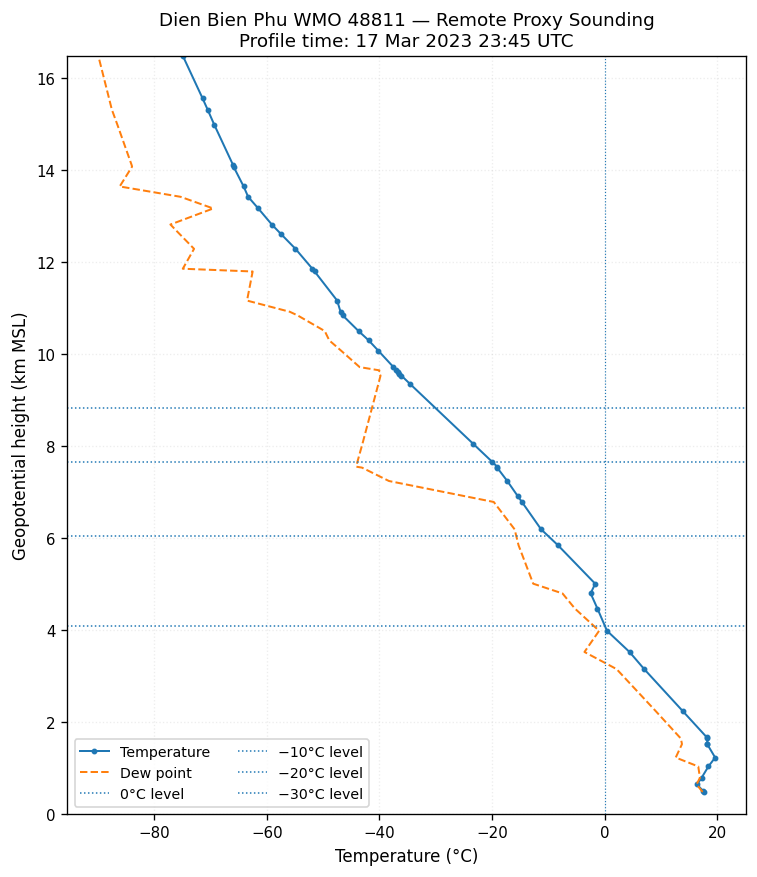

In [19]:
# CELL 19 — Sounding profile figure

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    fig = plt.figure(
        figsize=(
            6.2,
            7.2,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.plot(
        SOUNDING[
            "temperature_C"
        ],
        SOUNDING[
            "geopotential height_m"
        ]
        / 1000.0,
        marker="o",
        markersize=2.5,
        label="Temperature",
    )

    ax.plot(
        SOUNDING[
            "dew point temperature_C"
        ],
        SOUNDING[
            "geopotential height_m"
        ]
        / 1000.0,
        linestyle="--",
        label="Dew point",
    )

    thermal_lines = {
        "0°C level": (
            FREEZING_LEVEL_M_MSL
            / 1000.0
        ),
        "−10°C level": (
            MINUS10_LEVEL_M_MSL
            / 1000.0
        ),
        "−20°C level": (
            MINUS20_LEVEL_M_MSL
            / 1000.0
        ),
        "−30°C level": (
            MINUS30_LEVEL_M_MSL
            / 1000.0
        ),
    }

    for label, height_km in (
        thermal_lines.items()
    ):
        ax.axhline(
            height_km,
            linestyle=":",
            linewidth=0.9,
            label=label,
        )

    ax.axvline(
        0.0,
        linestyle=":",
        linewidth=0.7,
    )

    ax.set_xlabel(
        "Temperature (°C)"
    )

    ax.set_ylabel(
        "Geopotential height (km MSL)"
    )

    ax.set_title(
        (
            "Dien Bien Phu WMO 48811 — Remote Proxy Sounding\n"
            f"Profile time: {SOUNDING_PROFILE_TIME_UTC.strftime('%d %b %Y %H:%M UTC')}"
        )
    )

    ax.set_ylim(
        0.0,
        min(
            17.0,
            SOUNDING[
                "geopotential height_m"
            ].max()
            / 1000.0
        ),
    )

    ax.grid(
        alpha=0.22,
        linestyle=":",
    )

    ax.legend(
        frameon=True,
        ncol=2,
    )

    F = (
        FIGURE_DIR
        / "08_fig01_proxy_sounding_temperature_profile.png"
    )

    save_figure(
        fig,
        F,
        product="proxy sounding temperature profile",
        station=(
            PROXY_STATION_NAME
        ),
        wmo=(
            PROXY_STATION_WMO
        ),
        thermal_input_mode=(
            THERMAL_INPUT_MODE
        ),
        units="degree C and km MSL",
    )

    plt.show()

else:
    print(
        "Sounding profile figure not used in mode:",
        THERMAL_INPUT_MODE,
    )

# 17. Proxy representativeness summary

ค่าระยะและเวลาไม่ใช้เพื่อ “แก้” sounding

ใช้เพื่อบอก uncertainty อย่างโปร่งใส

Notebook จะตั้ง:

```text
spatial_proxy = True
temporal_proxy = True
local_environment_observation = False
```

สำหรับ Dien Bien Phu case

และจะบันทึกลงทุก processing metadata ที่เกี่ยวข้อง

In [20]:
# CELL 20 — Thermal provenance / representativeness table

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    THERMAL_PROVENANCE = pd.DataFrame({
        "parameter": [
            "thermal_input_mode",
            "thermal_source_type",
            "source_station",
            "source_WMO",
            "source_latitude_deg",
            "source_longitude_deg",
            "source_profile_time_UTC",
            "source_nominal_time_UTC",
            "peak_radar_time_UTC",
            "distance_source_to_radar_km",
            "distance_source_to_storm_reference_km",
            "profile_to_peak_offset_hours",
            "nominal_to_peak_offset_hours",
            "freezing_level_m_MSL",
            "minus10_level_m_MSL",
            "minus20_level_m_MSL",
            "minus30_level_m_MSL",
            "spatial_proxy",
            "temporal_proxy",
            "local_environment_observation",
            "publication_use_requires_explicit_limitation",
            "source_file",
            "source_url",
        ],
        "value": [
            THERMAL_INPUT_MODE,
            "remote observed sounding proxy",
            PROXY_STATION_NAME,
            PROXY_STATION_WMO,
            PROXY_STATION_LAT,
            PROXY_STATION_LON,
            str(
                SOUNDING_PROFILE_TIME_UTC
            ),
            str(
                PROXY_NOMINAL_TIME_UTC
            ),
            str(
                PEAK_RADAR_TIME_UTC
            ),
            DISTANCE_PROXY_TO_RADAR_KM,
            DISTANCE_PROXY_TO_STORM_KM,
            PROFILE_TO_PEAK_OFFSET_H,
            NOMINAL_TO_PEAK_OFFSET_H,
            FREEZING_LEVEL_M_MSL,
            MINUS10_LEVEL_M_MSL,
            MINUS20_LEVEL_M_MSL,
            MINUS30_LEVEL_M_MSL,
            True,
            True,
            False,
            True,
            str(
                proxy_path
            ),
            PROXY_SOUNDING_RAW_URL,
        ],
    })

else:
    THERMAL_PROVENANCE = pd.DataFrame({
        "parameter": [
            "thermal_input_mode",
            "thermal_source_type",
            "freezing_level_m_MSL",
            "minus10_level_m_MSL",
            "minus20_level_m_MSL",
            "minus30_level_m_MSL",
            "local_environment_observation",
            "publication_use_requires_explicit_limitation",
        ],
        "value": [
            THERMAL_INPUT_MODE,
            THERMAL_SOURCE_DESCRIPTION,
            FREEZING_LEVEL_M_MSL,
            MINUS10_LEVEL_M_MSL,
            MINUS20_LEVEL_M_MSL,
            MINUS30_LEVEL_M_MSL,
            LOCAL_ENVIRONMENT_OBSERVATION,
            True,
        ],
    })


display(
    THERMAL_PROVENANCE
)

THERMAL_PROVENANCE_CSV = (
    OUTPUT_CSV_DIR
    / "08_thermal_input_provenance.csv"
)

THERMAL_PROVENANCE.to_csv(
    THERMAL_PROVENANCE_CSV,
    index=False,
)

,parameter,value
0,thermal_input_mode,PROXY_SOUNDING
1,thermal_source_type,remote observed sounding proxy
2,source_station,Dien Bien Phu
3,source_WMO,48811
4,source_latitude_deg,21.37
5,source_longitude_deg,103.0
6,source_profile_time_UTC,2023-03-17 23:45:00+00:00
7,source_nominal_time_UTC,2023-03-18 00:00:00+00:00
8,peak_radar_time_UTC,2023-03-18 11:12:02+00:00
9,distance_source_to_radar_km,621.776365


# 18. Recommended interpretation language

สำหรับกรณี default นี้ ควรเขียนว่า:

> Environmental thermal levels were estimated from the 00 UTC 18 March 2023 upper-air sounding at Dien Bien Phu, Vietnam (WMO 48811), and were used as a remote proxy because a contemporaneous local sounding was unavailable near the Omkoi radar. The sounding was spatially and temporally separated from the hail-producing storm, and the resulting SHI/MESH products were therefore interpreted with explicit representativeness uncertainty.

ไม่ควรเขียนว่า:

```text
The Omkoi freezing level was ...
```

เพราะ sounding ไม่ได้อยู่ที่ Omkoi

# 19. อ่าน peak storm-focused 3-D grid

Peak-volume SHI/MESH ใช้ storm-focused 0.5-km 3-D grid จาก Notebook 03

ต้องตรวจ vertical reference อย่างระมัดระวัง

Notebook 03 ใช้ vertical coordinate แบบ MSL

สำหรับ pyhail copy จะกำหนด `radar_altitude = 0 m` เพื่อป้องกันการบวก altitude ซ้ำใน workflow ที่ใช้ `grid.z` เป็น MSL

In [21]:
# CELL 21 — Locate and read peak storm-focused grid

configured_storm_grid = Path(
    str(
        grid_config_lookup[
            "storm_grid_NetCDF"
        ]
    )
)

if configured_storm_grid.exists():
    STORM_GRID_NETCDF = (
        configured_storm_grid
    )

else:
    candidates = sorted(
        OUTPUT_NETCDF_DIR.glob(
            "03_peak_storm_focus_3D_ZH_*UTC.nc"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "Storm-focused 3-D Grid NetCDF not found."
        )

    STORM_GRID_NETCDF = (
        candidates[
            -1
        ]
    )


storm_grid = pyart.io.read_grid(
    str(
        STORM_GRID_NETCDF
    )
)

if FIELD_Z not in (
    storm_grid.fields
):
    raise KeyError(
        f"{FIELD_Z} is not available in the storm grid."
    )

STORM_X_KM = (
    np.asarray(
        storm_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_Y_KM = (
    np.asarray(
        storm_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_Z_KM_MSL = (
    np.asarray(
        storm_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_DX_KM = float(
    np.nanmedian(
        np.diff(
            STORM_X_KM
        )
    )
)

STORM_DY_KM = float(
    np.nanmedian(
        np.diff(
            STORM_Y_KM
        )
    )
)

STORM_DZ_KM = float(
    np.nanmedian(
        np.diff(
            STORM_Z_KM_MSL
        )
    )
)

print(
    "Storm grid:",
    STORM_GRID_NETCDF,
)

print(
    "Shape:",
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

print(
    "Spacing:",
    f"{STORM_DX_KM:.2f} × "
    f"{STORM_DY_KM:.2f} × "
    f"{STORM_DZ_KM:.2f} km",
)

Storm grid: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/netcdf/03_peak_storm_focus_3D_ZH_20230318_111202UTC.nc
Shape: (38, 329, 422)
Spacing: 0.50 × 0.50 × 0.50 km


In [22]:
# CELL 22 — Prepare pyhail grid copy

GRID_VERTICAL_REFERENCE = str(
    grid_config_lookup.get(
        "vertical_reference",
        "MSL",
    )
)

storm_grid_pyhail = copy.deepcopy(
    storm_grid
)

if (
    GRID_VERTICAL_REFERENCE.upper()
    == "MSL"
):
    storm_grid_pyhail.radar_altitude[
        "data"
    ] = np.array(
        [
            0.0
        ],
        dtype=float,
    )

print(
    "Grid vertical reference:",
    GRID_VERTICAL_REFERENCE,
)

print(
    "pyhail-copy radar_altitude:",
    storm_grid_pyhail.radar_altitude[
        "data"
    ],
)

Grid vertical reference: MSL
pyhail-copy radar_altitude: [0.]


# 20. Robust pyhail wrapper

Software API สามารถเปลี่ยนได้ระหว่าง versions

แม้ Notebook pin `pyhail==3.4.2` เราจะ:

1. inspect signature
2. ส่งเฉพาะ keyword ที่ function รองรับ
3. รองรับ output field name ทั้ง `mesh` และ `mesh_<method>`
4. รองรับทั้งกรณี function return dictionary และกรณี field ถูกเพิ่มใน Grid

วิธีนี้ทำให้ teaching code อธิบายได้และลดความเปราะบาง

## Rectangular-grid compatibility note

Peak storm grid ของกรณีนี้มีรูปแบบ:

```text
(nz, ny, nx) = (38, 422, 329)
```

คือ horizontal grid เป็น **rectangular grid** ไม่ใช่ square grid

ใน `pyhail 3.4.2` ฟังก์ชัน grid-MESH สร้าง altitude array ด้วยลำดับ x/y ที่สลับกัน
ซึ่งให้ shape:

```text
(38, 329, 422)
```

ขณะที่ corrected-reflectivity grid มี shape:

```text
(38, 422, 329)
```

จึงไม่สามารถคูณ temperature weighting กับ hail kinetic energy ได้

Notebook นี้แก้เฉพาะ compatibility ของ **array geometry** โดยใช้:

```python
alt_grid = alt_vec[:, None, None]
```

ซึ่ง broadcast ตามมาตรฐาน Py-ART:

```text
(nz, ny, nx)
```

สมการ SHI และ MESH calibration ยังคงใช้ formulation ของ `pyhail`
และ MESH calibration functions จาก package โดยตรง

> การแก้นี้ไม่ transpose radar data และไม่เปลี่ยนตำแหน่งเชิงพื้นที่ของ storm grid

In [23]:
# CELL 23 — Robust mesh_grid runner with rectangular-grid compatibility

from pyhail import common as pyhail_common
from pyhail.mesh_formulas import (
    mesh_witt1998,
    mesh_mh2019_75,
    mesh_mh2019_95,
    mesh_smooth_blend,
)


def _run_mesh_grid_rectangular_compat(
    grid_object,
    *,
    field_name,
    temp_levels_m_MSL,
    mesh_method,
):
    """
    Compatibility implementation for pyhail 3.4.2 on a non-square
    Py-ART Cartesian grid.

    Scientific equations and MESH calibration functions follow pyhail.
    The only material geometry correction is the altitude-grid construction:

        official implementation:
            alt_grid shape -> (nz, nx, ny) for a rectangular grid

        corrected implementation:
            alt_grid = alt_vec[:, None, None]
            broadcasts as (nz, ny, nx)

    This avoids transposing the radar field and therefore preserves the
    Py-ART convention field.shape == (nz, ny, nx).
    """

    dbz_grid = np.ma.asarray(
        grid_object.fields[
            field_name
        ][
            "data"
        ]
    ).copy()

    grid_shape = (
        dbz_grid.shape
    )

    if len(
        grid_shape
    ) != 3:
        raise ValueError(
            "Expected a 3-D Py-ART grid field with shape (nz, ny, nx). "
            f"Got {grid_shape}."
        )

    nz, ny, nx = (
        grid_shape
    )

    alt_vec = (
        np.asarray(
            grid_object.z[
                "data"
            ],
            dtype=float,
        )
        + float(
            grid_object.radar_altitude[
                "data"
            ][0]
        )
    )

    if len(
        alt_vec
    ) != nz:
        raise ValueError(
            "Vertical coordinate length does not match reflectivity grid: "
            f"len(z)={len(alt_vec)}, nz={nz}."
        )

    # Correct broadcasting for any rectangular grid:
    # (nz, 1, 1) -> (nz, ny, nx)
    alt_grid = (
        alt_vec[
            :,
            None,
            None
        ]
    )

    meltlayer = float(
        min(
            temp_levels_m_MSL
        )
    )

    neg20layer = float(
        max(
            temp_levels_m_MSL
        )
    )

    if not (
        meltlayer
        < neg20layer
    ):
        raise ValueError(
            "The freezing level must be lower than the −20°C level."
        )

    # --------------------------------------------------------------
    # Reflectivity weighting — same physical formulation as pyhail
    # --------------------------------------------------------------
    z_l = 40.0
    z_u = 50.0

    dbz_work = (
        dbz_grid.filled(
            np.nan
        ).astype(
            float
        )
    )

    # Omkoi is S-band, so no C-band correction is applied.
    dbz_weights = (
        (
            dbz_work
            - z_l
        )
        / (
            z_u
            - z_l
        )
    )

    dbz_weights[
        dbz_work
        <= z_l
    ] = 0.0

    dbz_weights[
        dbz_work
        >= z_u
    ] = 1.0

    dbz_weights[
        ~np.isfinite(
            dbz_work
        )
    ] = 0.0

    dbz_work = np.clip(
        dbz_work,
        -100.0,
        100.0,
    )

    # Hail kinetic-energy proxy.
    hke = (
        5.0e-6
        * np.power(
            10.0,
            0.084
            * dbz_work,
        )
        * dbz_weights
    )

    hke[
        ~np.isfinite(
            hke
        )
    ] = 0.0

    # --------------------------------------------------------------
    # Temperature-height weighting
    # --------------------------------------------------------------
    w_t = (
        (
            alt_grid
            - meltlayer
        )
        / (
            neg20layer
            - meltlayer
        )
    )

    w_t = np.clip(
        w_t,
        0.0,
        1.0,
    )

    # --------------------------------------------------------------
    # Severe Hail Index
    # --------------------------------------------------------------
    if nz < 2:
        raise ValueError(
            "At least two vertical grid levels are required for SHI."
        )

    dz_values = np.diff(
        alt_vec
    )

    if not np.all(
        np.isfinite(
            dz_values
        )
    ):
        raise ValueError(
            "Vertical grid spacing contains non-finite values."
        )

    # Notebook 03 uses a uniform vertical grid.
    # Retain pyhail's uniform-dz formulation but verify it explicitly.
    dz_m = float(
        np.nanmedian(
            dz_values
        )
    )

    if not np.allclose(
        dz_values,
        dz_m,
        rtol=0.0,
        atol=1.0e-6,
    ):
        raise ValueError(
            "The rectangular compatibility path expects a uniform "
            "vertical grid, matching the current Notebook 03 configuration."
        )

    shi = (
        0.1
        * np.sum(
            w_t
            * hke,
            axis=0,
        )
        * dz_m
    )

    # --------------------------------------------------------------
    # MESH calibration — use pyhail's own formulation functions
    # --------------------------------------------------------------
    if mesh_method == "witt1998":
        mesh = mesh_witt1998(
            shi
        )

    elif mesh_method == "mh2019_75":
        mesh = mesh_mh2019_75(
            shi
        )

    elif mesh_method == "mh2019_95":
        mesh = mesh_mh2019_95(
            shi
        )

    elif mesh_method == "blend":
        mesh = mesh_smooth_blend(
            shi,
            transition_width=(
                PYHAIL_TRANSITION_WIDTH
            ),
        )

    else:
        raise ValueError(
            "Unknown MESH method. Use witt1998, mh2019_75, "
            "mh2019_95, or blend."
        )

    # --------------------------------------------------------------
    # POSH — same Witt/pyhail framework
    # --------------------------------------------------------------
    warning_threshold = (
        57.5
        * (
            meltlayer
            / 1000.0
        )
        - 121.0
    )

    if warning_threshold <= 0.0:
        raise ValueError(
            "The POSH warning threshold is non-positive; "
            "review the freezing-level input."
        )

    posh = (
        29.0
        * pyhail_common.safe_log(
            shi
            / warning_threshold
        )
        + 50.0
    )

    posh[
        posh
        < 0.0
    ] = 0.0

    posh[
        posh
        > 100.0
    ] = 100.0

    # Reproduce pyhail's current speckle-filter behavior:
    # SHI is filtered after MESH/POSH are computed.
    if PYHAIL_SPECKLE_FILTER:
        shi = (
            mesh_grid.filter_small_objects(
                shi
            )
        )

    # --------------------------------------------------------------
    # Near-radar mask
    # --------------------------------------------------------------
    if (
        PYHAIL_NEAR_RADAR_MASK_M
        is not None
    ):
        x_2d, y_2d = (
            np.meshgrid(
                np.asarray(
                    grid_object.x[
                        "data"
                    ],
                    dtype=float,
                ),
                np.asarray(
                    grid_object.y[
                        "data"
                    ],
                    dtype=float,
                ),
            )
        )

        near_mask = (
            np.hypot(
                x_2d,
                y_2d,
            )
            < PYHAIL_NEAR_RADAR_MASK_M
        )

        shi[
            near_mask
        ] = np.nan

        mesh[
            near_mask
        ] = np.nan

        posh[
            near_mask
        ] = np.nan

    # --------------------------------------------------------------
    # Return field dictionaries in pyhail-compatible form
    # --------------------------------------------------------------
    shi_grid = np.full(
        (
            nz,
            ny,
            nx,
        ),
        np.nan,
        dtype=float,
    )

    mesh_grid_out = np.full(
        (
            nz,
            ny,
            nx,
        ),
        np.nan,
        dtype=float,
    )

    posh_grid = np.full(
        (
            nz,
            ny,
            nx,
        ),
        np.nan,
        dtype=float,
    )

    shi_grid[
        0,
        :,
        :
    ] = shi

    mesh_grid_out[
        0,
        :,
        :
    ] = mesh

    posh_grid[
        0,
        :,
        :
    ] = posh

    output_fields = {
        "hail_ke": {
            "data": (
                hke
            ),
            "units": (
                "Jm-2s-1"
            ),
            "long_name": (
                "Hail Kinetic Energy"
            ),
            "comments": (
                "Rectangular-grid compatibility calculation using "
                "the pyhail physical formulation."
            ),
        },
        "shi": {
            "data": (
                shi_grid
            ),
            "units": (
                "Jm-1s-1"
            ),
            "long_name": (
                "Severe Hail Index"
            ),
            "comments": (
                "Only valid in the first level of the 3-D output."
            ),
        },
        (
            "mesh_"
            + mesh_method
        ): {
            "data": (
                mesh_grid_out
            ),
            "units": (
                "mm"
            ),
            "long_name": (
                "Maximum Expected Size of Hail using "
                + mesh_method
            ),
            "comments": (
                "Only valid in the first level of the 3-D output."
            ),
        },
        "posh": {
            "data": (
                posh_grid
            ),
            "units": (
                "%"
            ),
            "long_name": (
                "Probability of Severe Hail"
            ),
            "comments": (
                "Algorithm output; not locally calibrated probability."
            ),
        },
    }

    return {
        "result": (
            output_fields
        ),
        "grid": (
            grid_object
        ),
        "supported_kwargs": {
            "rectangular_grid_compatibility": True,
            "original_grid_shape": (
                grid_shape
            ),
        },
        "signature": (
            "local rectangular-grid compatibility path "
            "using pyhail 3.4.2 equations/formulas"
        ),
    }


def run_mesh_grid_pyhail(
    grid_object,
    *,
    field_name,
    temp_levels_m_MSL,
    mesh_method,
):
    """
    Run official pyhail on square grids.

    For non-square Py-ART grids, use a documented compatibility path
    because pyhail 3.4.2 constructs the altitude grid with x/y swapped,
    causing a broadcasting error when ny != nx.
    """

    grid_shape = tuple(
        np.ma.asarray(
            grid_object.fields[
                field_name
            ][
                "data"
            ]
        ).shape
    )

    if len(
        grid_shape
    ) != 3:
        raise ValueError(
            f"Expected 3-D grid data, got {grid_shape}."
        )

    nz, ny, nx = (
        grid_shape
    )

    print(
        "pyhail input grid:",
        f"(nz, ny, nx) = {grid_shape}"
    )

    if ny != nx:
        print(
            "Non-square horizontal grid detected "
            f"(ny={ny}, nx={nx})."
        )

        print(
            "Using rectangular-grid compatibility path "
            "to preserve (nz, ny, nx) orientation."
        )

        return (
            _run_mesh_grid_rectangular_compat(
                grid_object,
                field_name=(
                    field_name
                ),
                temp_levels_m_MSL=(
                    temp_levels_m_MSL
                ),
                mesh_method=(
                    mesh_method
                ),
            )
        )

    # Square grid: use official pyhail directly.
    function = getattr(
        mesh_grid,
        "main",
        None,
    )

    if function is None:
        raise RuntimeError(
            "pyhail.mesh_grid.main is unavailable."
        )

    signature = inspect.signature(
        function
    )

    candidate_kwargs = {
        "radar_band": (
            RADAR_BAND
        ),
        "mesh_method": (
            mesh_method
        ),
        "speckle_filter": (
            PYHAIL_SPECKLE_FILTER
        ),
        "correct_cband_refl": False,
        "transition_width": (
            PYHAIL_TRANSITION_WIDTH
        ),
        "near_radar_mask_range": (
            PYHAIL_NEAR_RADAR_MASK_M
        ),
    }

    supported_kwargs = {
        key: value
        for key, value in (
            candidate_kwargs.items()
        )
        if key in (
            signature.parameters
        )
    }

    grid_copy = copy.deepcopy(
        grid_object
    )

    result = function(
        grid_copy,
        field_name,
        temp_levels_m_MSL,
        **supported_kwargs,
    )

    return {
        "result": (
            result
        ),
        "grid": (
            grid_copy
        ),
        "supported_kwargs": (
            supported_kwargs
        ),
        "signature": str(
            signature
        ),
    }


def find_hail_output_field(
    run_output,
    candidate_names,
):
    result = (
        run_output[
            "result"
        ]
    )

    grid_object = (
        run_output[
            "grid"
        ]
    )

    if isinstance(
        result,
        dict,
    ):
        for name in (
            candidate_names
        ):
            if name in result:
                return (
                    name,
                    result[
                        name
                    ],
                )

    for name in (
        candidate_names
    ):
        if name in (
            grid_object.fields
        ):
            return (
                name,
                grid_object.fields[
                    name
                ],
            )

    raise KeyError(
        "Could not find any output field among: "
        + str(
            candidate_names
        )
    )


def field_dict_to_2d(
    field_dict,
):
    data = np.ma.asarray(
        field_dict[
            "data"
        ]
    )

    if data.ndim == 3:
        data = (
            data[
                0
            ]
        )

    if data.ndim != 2:
        raise ValueError(
            f"Expected 2-D or 3-D hail output, got shape {data.shape}."
        )

    return data.filled(
        np.nan
    )

# 21. Run SHI / MESH / POSH สำหรับ 4 formulations

ใช้ thermal levels:

```text
0°C
−20°C
```

จาก thermal mode ที่เลือก

Default:

```text
PROXY_SOUNDING
```

ผลจาก MESH formulations เป็น **algorithm sensitivity**

In [24]:
# CELL 24 — Run four pyhail MESH formulations

PEAK_PYHAIL_RUNS = {}

for method in (
    MESH_METHODS
):
    print(
        "Running:",
        method,
    )

    PEAK_PYHAIL_RUNS[
        method
    ] = (
        run_mesh_grid_pyhail(
            storm_grid_pyhail,
            field_name=(
                FIELD_Z
            ),
            temp_levels_m_MSL=(
                PYHAIL_LEVELS_M_MSL
            ),
            mesh_method=(
                method
            ),
        )
    )

print(
    "Peak SHI/MESH processing complete."
)

Running: witt1998
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.
Running: mh2019_75
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.
Running: mh2019_95
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.
Running: blend
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.
Peak SHI/MESH processing complete.


In [25]:
# CELL 25 — Extract SHI, POSH and MESH arrays robustly

PEAK_MESH = {}

primary_run = (
    PEAK_PYHAIL_RUNS[
        PRIMARY_MESH_METHOD
    ]
)

_, shi_field = (
    find_hail_output_field(
        primary_run,
        [
            "shi",
            "SHI",
        ],
    )
)

PEAK_SHI = field_dict_to_2d(
    shi_field
)

_, posh_field = (
    find_hail_output_field(
        primary_run,
        [
            "posh",
            "POSH",
        ],
    )
)

PEAK_POSH = field_dict_to_2d(
    posh_field
)


for method in (
    MESH_METHODS
):
    run = (
        PEAK_PYHAIL_RUNS[
            method
        ]
    )

    mesh_name, mesh_field = (
        find_hail_output_field(
            run,
            [
                "mesh_"
                + method,
                "mesh",
                "MESH",
            ],
        )
    )

    PEAK_MESH[
        method
    ] = field_dict_to_2d(
        mesh_field
    )

    print(
        method,
        "→",
        mesh_name,
    )

witt1998 → mesh_witt1998
mh2019_75 → mesh_mh2019_75
mh2019_95 → mesh_mh2019_95
blend → mesh_blend


In [26]:
# CELL 26 — Peak pyhail output inventory

output_rows = []

for method in (
    MESH_METHODS
):
    mesh_data = (
        PEAK_MESH[
            method
        ]
    )

    valid_mesh = mesh_data[
        np.isfinite(
            mesh_data
        )
    ]

    output_rows.append({
        "mesh_method": (
            method
        ),
        "maximum_MESH_mm": (
            float(
                np.nanmax(
                    valid_mesh
                )
            )
            if valid_mesh.size
            else np.nan
        ),
        "valid_MESH_pixel_count": int(
            valid_mesh.size
        ),
    })


output_rows.append({
    "mesh_method": "SHI",
    "maximum_MESH_mm": (
        float(
            np.nanmax(
                PEAK_SHI
            )
        )
        if np.isfinite(
            PEAK_SHI
        ).any()
        else np.nan
    ),
    "valid_MESH_pixel_count": int(
        np.isfinite(
            PEAK_SHI
        ).sum()
    ),
})

output_rows.append({
    "mesh_method": "POSH",
    "maximum_MESH_mm": (
        float(
            np.nanmax(
                PEAK_POSH
            )
        )
        if np.isfinite(
            PEAK_POSH
        ).any()
        else np.nan
    ),
    "valid_MESH_pixel_count": int(
        np.isfinite(
            PEAK_POSH
        ).sum()
    ),
})


PYHAIL_OUTPUT_INVENTORY = pd.DataFrame(
    output_rows
)

display(
    PYHAIL_OUTPUT_INVENTORY
)

PYHAIL_OUTPUT_INVENTORY_CSV = (
    OUTPUT_CSV_DIR
    / "08_pyhail_peak_output_inventory.csv"
)

PYHAIL_OUTPUT_INVENTORY.to_csv(
    PYHAIL_OUTPUT_INVENTORY_CSV,
    index=False,
)

,mesh_method,maximum_MESH_mm,valid_MESH_pixel_count
0,witt1998,46.199481,137593
1,mh2019_75,49.877064,137593
2,mh2019_95,75.799718,137593
3,blend,46.578616,137593
4,SHI,330.831425,137593
5,POSH,80.810356,137593


# 22. Peak SHI map

SHI บอก hail-production potential จาก combination ของ:

```text
high reflectivity
+
vertical depth
+
thermal weighting
```

แต่ SHI ไม่ใช่ hail report และไม่ใช่ hail diameter

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_SHI.png


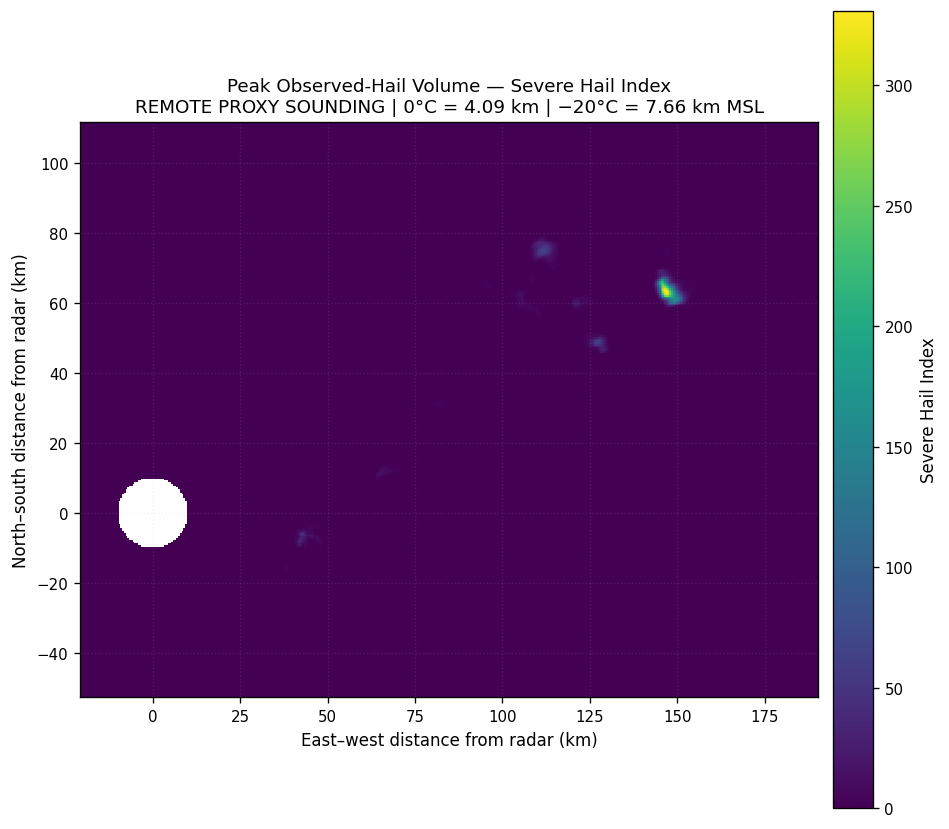

In [27]:
# CELL 27 — Peak SHI map

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_SHI
    ),
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Severe Hail Index"
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

title_prefix = (
    "REMOTE PROXY SOUNDING"
    if THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
    else THERMAL_SOURCE_LABEL
)

ax.set_title(
    (
        "Peak Observed-Hail Volume — Severe Hail Index\n"
        f"{title_prefix} | "
        f"0°C = {FREEZING_LEVEL_M_MSL/1000:.2f} km | "
        f"−20°C = {MINUS20_LEVEL_M_MSL/1000:.2f} km MSL"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / (
        "08_"
        f"{THERMAL_SOURCE_LABEL}_peak_SHI.png"
    )
)

save_figure(
    fig,
    F,
    product="SHI",
    thermal_source=(
        THERMAL_SOURCE_LABEL
    ),
    units="algorithm units",
)

plt.show()

# 23. MESH formulation maps

ใช้ spatial extent และ color scale เดียวกันสำหรับทุก formulation

เพื่อให้เปรียบเทียบ:

```text
pattern
maximum
gradient
footprint
```

โดยไม่ให้ plotting choices ทำให้เข้าใจผิด

In [28]:
# CELL 28 — Common MESH display scale

all_mesh_values = np.concatenate(
    [
        array[
            np.isfinite(
                array
            )
        ]
        for array in (
            PEAK_MESH.values()
        )
        if np.isfinite(
            array
        ).any()
    ]
)

MESH_DISPLAY_MAX_MM = (
    max(
        60.0,
        float(
            np.nanpercentile(
                all_mesh_values,
                99,
            )
        ),
    )
    if all_mesh_values.size
    else 60.0
)

MESH_DISPLAY_MAX_MM = min(
    MESH_DISPLAY_MAX_MM,
    150.0,
)

print(
    "Common MESH display maximum:",
    f"{MESH_DISPLAY_MAX_MM:.1f} mm",
)

Common MESH display maximum: 60.0 mm


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_MESH_witt1998.png


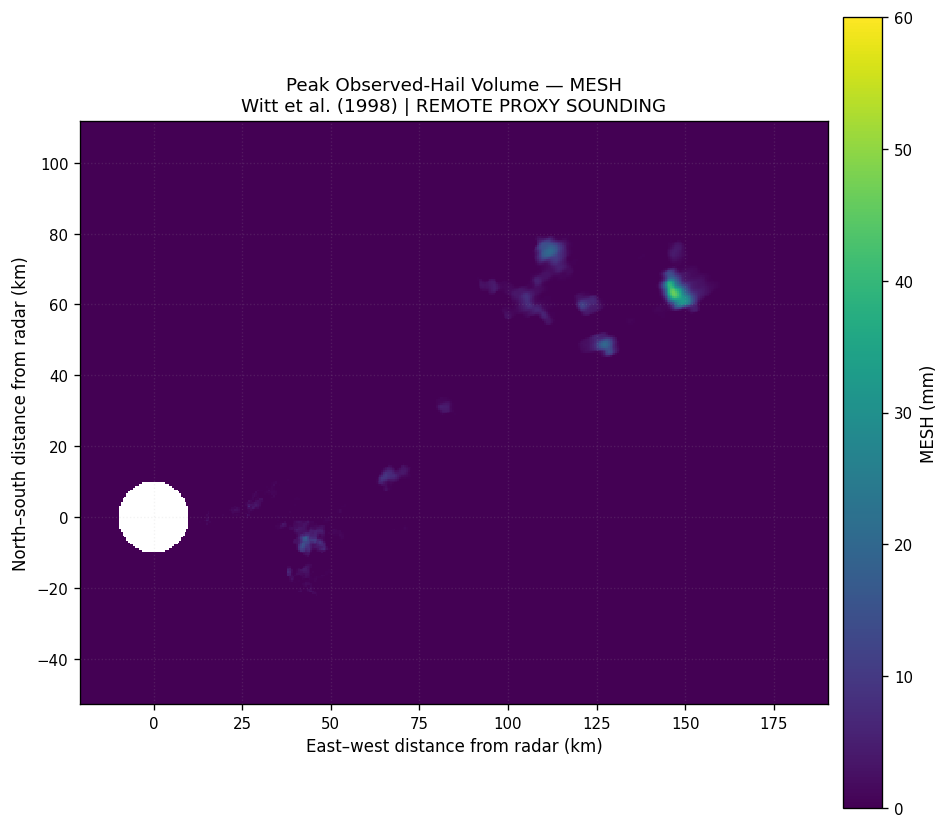

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_75.png


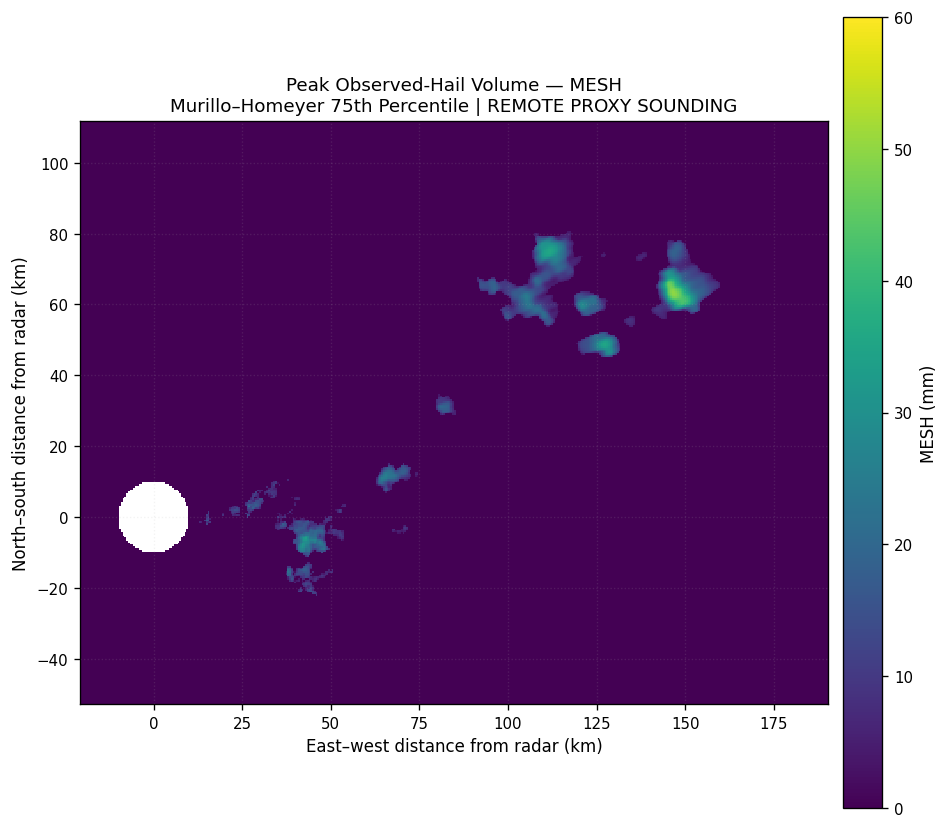

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_95.png


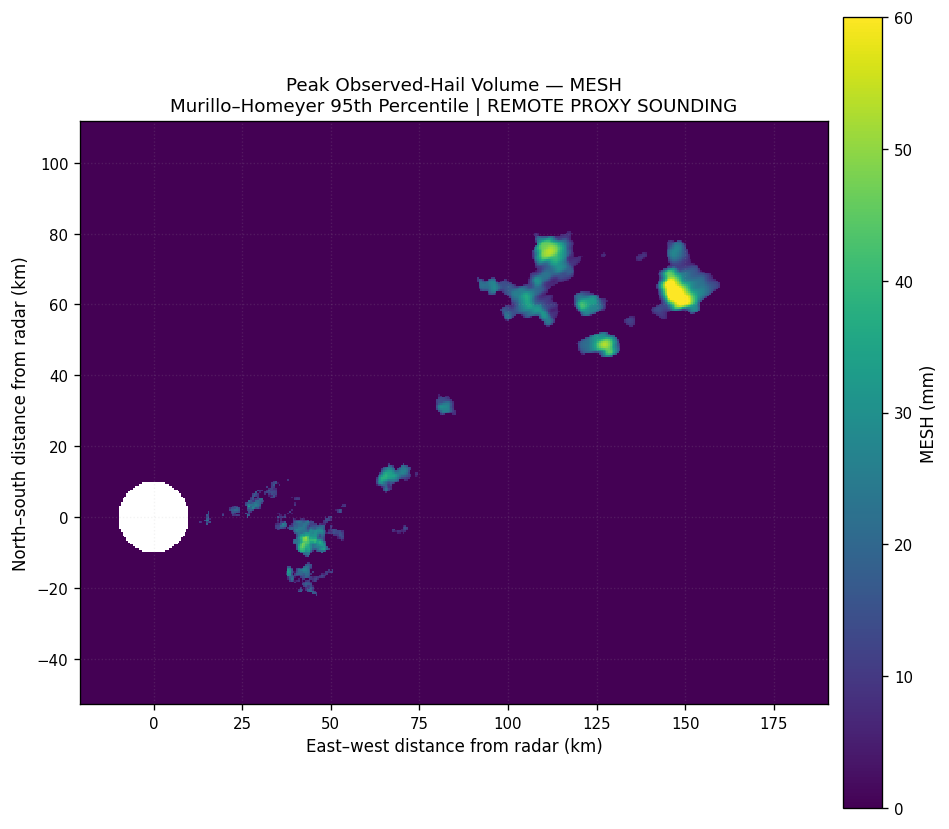

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_MESH_blend.png


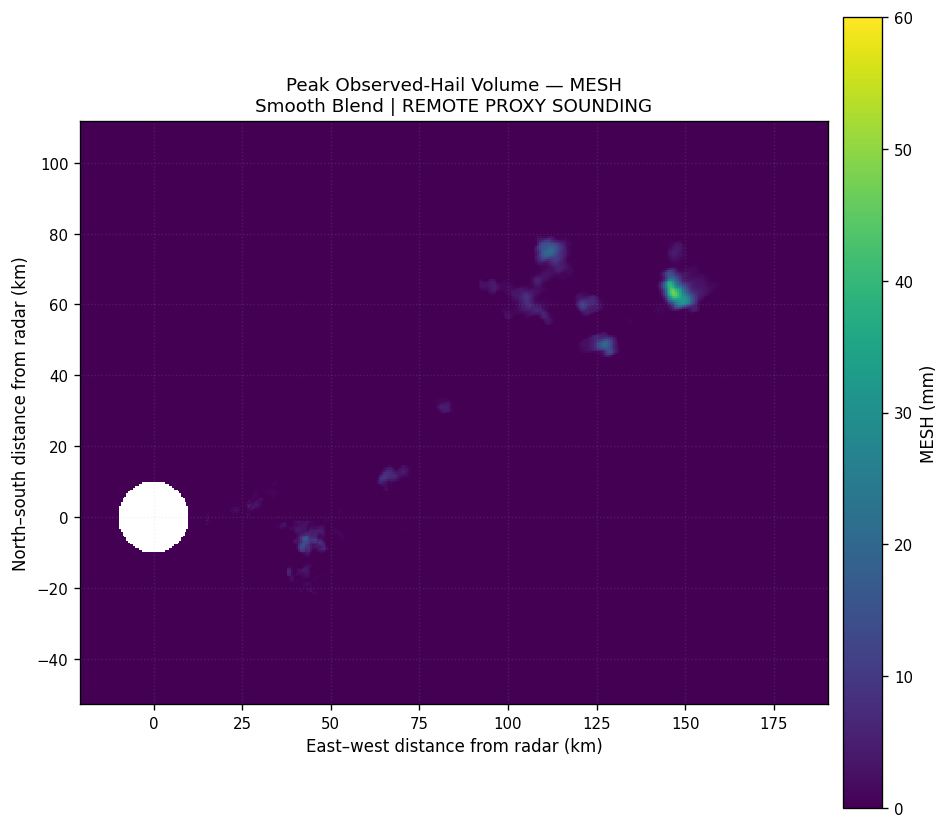

In [29]:
# CELL 29 — Plot MESH formulations

method_labels = {
    "witt1998": (
        "Witt et al. (1998)"
    ),
    "mh2019_75": (
        "Murillo–Homeyer 75th Percentile"
    ),
    "mh2019_95": (
        "Murillo–Homeyer 95th Percentile"
    ),
    "blend": (
        "Smooth Blend"
    ),
}

for method in (
    MESH_METHODS
):
    data = (
        PEAK_MESH[
            method
        ]
    )

    fig = plt.figure(
        figsize=(
            7.8,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        STORM_X_KM,
        STORM_Y_KM,
        np.ma.masked_invalid(
            data
        ),
        shading="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=(
            MESH_DISPLAY_MAX_MM
        ),
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "MESH (mm)"
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        (
            "Peak Observed-Hail Volume — MESH\n"
            f"{method_labels[method]} | "
            f"{title_prefix}"
        )
    )

    ax.grid(
        alpha=0.15,
        linestyle=":",
    )

    F = (
        FIGURE_DIR
        / (
            "08_"
            f"{THERMAL_SOURCE_LABEL}_"
            f"peak_MESH_{method}.png"
        )
    )

    save_figure(
        fig,
        F,
        product="MESH",
        mesh_method=(
            method
        ),
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
        units="mm",
    )

    plt.show()

# 24. POSH map

POSH ใน pyhail เป็น algorithm output ภายใต้ Witt framework

ใน Notebook นี้:

```text
POSH ≠ Thailand-calibrated probability
```

จึงใช้เพื่อสอน retrieval behavior และเปรียบเทียบภายในเหตุการณ์เท่านั้น

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_peak_POSH.png


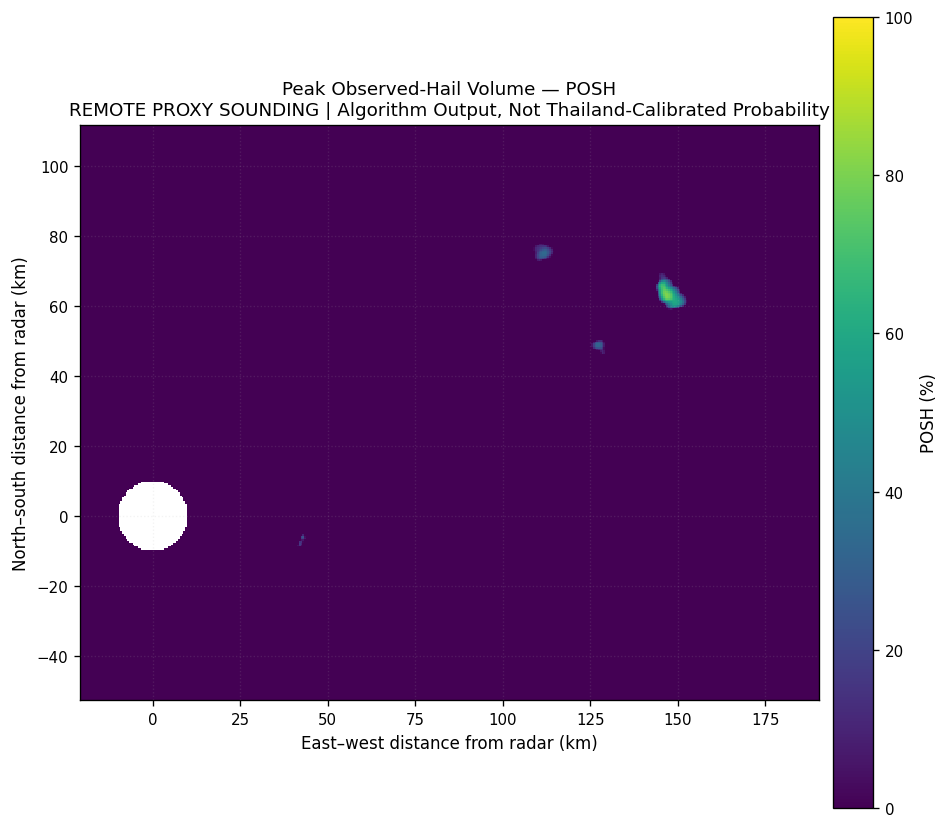

In [30]:
# CELL 30 — POSH map

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_POSH
    ),
    shading="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=100.0,
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "POSH (%)"
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Peak Observed-Hail Volume — POSH\n"
        f"{title_prefix} | "
        "Algorithm Output, Not Thailand-Calibrated Probability"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / (
        "08_"
        f"{THERMAL_SOURCE_LABEL}_peak_POSH.png"
    )
)

save_figure(
    fig,
    F,
    product="POSH",
    thermal_source=(
        THERMAL_SOURCE_LABEL
    ),
    units="percent",
)

plt.show()

# 25. Formulation sensitivity table

สำหรับแต่ละ MESH formulation จะสรุป:

- maximum
- median ของ positive values
- P90
- P95
- area ≥10 / 20 / 25 / 40 / 50 / 75 mm

Area exceedance เป็นพื้นที่ที่ **algorithm estimate** ผ่าน threshold  
ไม่ใช่ observed hail-swath area

In [31]:
# CELL 31 — Peak MESH formulation sensitivity

pixel_area_km2 = (
    STORM_DX_KM
    * STORM_DY_KM
)

mesh_summary_rows = []

for method in (
    MESH_METHODS
):
    data = (
        PEAK_MESH[
            method
        ]
    )

    valid = np.isfinite(
        data
    )

    positive = (
        valid
        & (
            data
            > 0.0
        )
    )

    values = (
        data[
            positive
        ]
    )

    row = {
        "mesh_method": (
            method
        ),
        "thermal_source": (
            THERMAL_SOURCE_LABEL
        ),
        "valid_pixel_count": int(
            valid.sum()
        ),
        "positive_mesh_pixel_count": int(
            positive.sum()
        ),
        "maximum_MESH_mm": (
            float(
                np.nanmax(
                    values
                )
            )
            if values.size
            else np.nan
        ),
        "median_positive_MESH_mm": (
            float(
                np.nanmedian(
                    values
                )
            )
            if values.size
            else np.nan
        ),
        "P90_positive_MESH_mm": (
            float(
                np.nanpercentile(
                    values,
                    90,
                )
            )
            if values.size
            else np.nan
        ),
        "P95_positive_MESH_mm": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
    }

    for threshold in (
        MESH_EXCEEDANCE_THRESHOLDS_MM
    ):
        row[
            f"area_ge_{int(threshold)}mm_km2"
        ] = float(
            (
                valid
                & (
                    data
                    >= threshold
                )
            ).sum()
            * pixel_area_km2
        )

    mesh_summary_rows.append(
        row
    )


PEAK_MESH_SENSITIVITY = pd.DataFrame(
    mesh_summary_rows
)

display(
    PEAK_MESH_SENSITIVITY
)

PEAK_MESH_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "08_peak_MESH_formulation_sensitivity.csv"
)

PEAK_MESH_SENSITIVITY.to_csv(
    PEAK_MESH_SENSITIVITY_CSV,
    index=False,
)

,mesh_method,thermal_source,valid_pixel_count,positive_mesh_pixel_count,maximum_MESH_mm,median_positive_MESH_mm,P90_positive_MESH_mm,P95_positive_MESH_mm,area_ge_10mm_km2,area_ge_20mm_km2,area_ge_25mm_km2,area_ge_40mm_km2,area_ge_50mm_km2,area_ge_75mm_km2
0,witt1998,PROXY_OBSERVED_WMO48811,137593,3857,46.199481,1.978067,11.219507,17.928126,110.75,37.50,27.75,5.75,0.00,0.00
1,mh2019_75,PROXY_OBSERVED_WMO48811,137593,3857,49.877064,13.618262,27.839380,33.769666,646.75,222.25,130.25,24.75,0.00,0.00
2,mh2019_95,PROXY_OBSERVED_WMO48811,137593,3857,75.799718,19.928180,41.595880,50.741143,802.75,479.50,325.75,108.00,50.75,1.25
3,blend,PROXY_OBSERVED_WMO48811,137593,3857,46.578616,1.979012,11.221550,17.931916,110.75,37.50,27.75,5.75,0.00,0.00


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_MESH_formulation_sensitivity.png


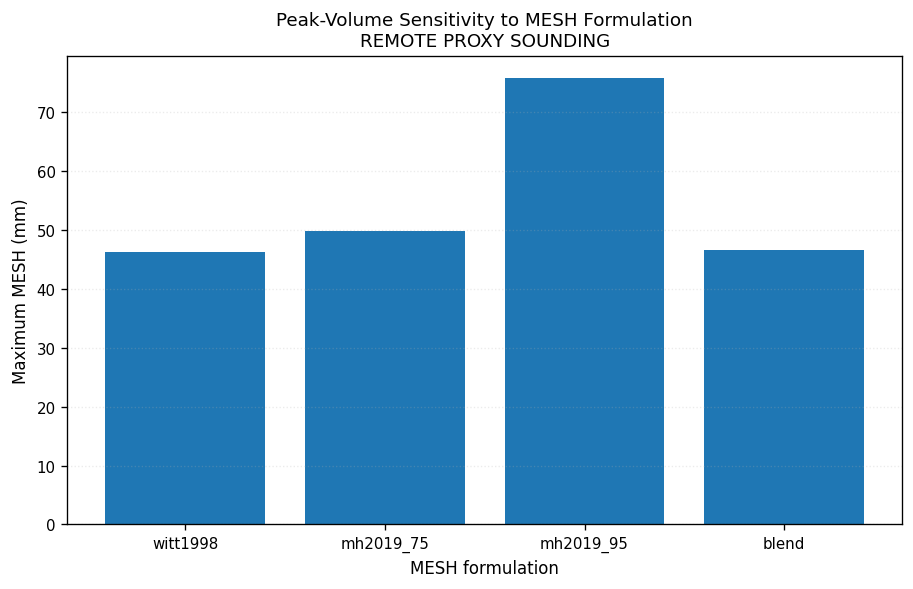

In [32]:
# CELL 32 — Maximum MESH by formulation

fig = plt.figure(
    figsize=(
        7.5,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.bar(
    PEAK_MESH_SENSITIVITY[
        "mesh_method"
    ],
    PEAK_MESH_SENSITIVITY[
        "maximum_MESH_mm"
    ],
)

ax.set_xlabel(
    "MESH formulation"
)

ax.set_ylabel(
    "Maximum MESH (mm)"
)

ax.set_title(
    (
        "Peak-Volume Sensitivity to MESH Formulation\n"
        f"{title_prefix}"
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / (
        "08_"
        f"{THERMAL_SOURCE_LABEL}_"
        "MESH_formulation_sensitivity.png"
    )
)

save_figure(
    fig,
    F,
    product="MESH formulation sensitivity",
    thermal_source=(
        THERMAL_SOURCE_LABEL
    ),
    units="mm",
)

plt.show()

# 26. Proxy thermal-level sensitivity ±500 m

Remote proxy sounding มี representativeness uncertainty

Notebook จึงใช้ proxy-derived thermal levels เป็น BASE แล้ว perturb:

```text
LOW  = BASE − 500 m
BASE = proxy sounding
HIGH = BASE + 500 m
```

โดยเลื่อนทั้ง 0°C และ −20°C levels พร้อมกัน

เป้าหมายไม่ใช่บอกว่า uncertainty จริงเท่ากับ ±500 m

แต่เพื่อสอนว่า:

```text
uncertainty in environment
→ uncertainty in SHI/MESH/POSH
```

ค่าการ perturb เป็น **teaching sensitivity parameter**

In [33]:
# CELL 33 — Define thermal sensitivity scenarios

THERMAL_SCENARIOS = {
    "LOW": {
        "freezing_level_m_MSL": (
            FREEZING_LEVEL_M_MSL
            - THERMAL_PERTURBATION_M
        ),
        "minus20_level_m_MSL": (
            MINUS20_LEVEL_M_MSL
            - THERMAL_PERTURBATION_M
        ),
    },
    "BASE": {
        "freezing_level_m_MSL": (
            FREEZING_LEVEL_M_MSL
        ),
        "minus20_level_m_MSL": (
            MINUS20_LEVEL_M_MSL
        ),
    },
    "HIGH": {
        "freezing_level_m_MSL": (
            FREEZING_LEVEL_M_MSL
            + THERMAL_PERTURBATION_M
        ),
        "minus20_level_m_MSL": (
            MINUS20_LEVEL_M_MSL
            + THERMAL_PERTURBATION_M
        ),
    },
}

display(
    pd.DataFrame(
        [
            {
                "scenario": (
                    scenario
                ),
                **values,
            }
            for scenario, values in (
                THERMAL_SCENARIOS.items()
            )
        ]
    )
)

,scenario,freezing_level_m_MSL,minus20_level_m_MSL
0,LOW,3592.882353,7158.0
1,BASE,4092.882353,7658.0
2,HIGH,4592.882353,8158.0


In [34]:
# CELL 34 — Run thermal sensitivity using primary blended MESH

THERMAL_SENSITIVITY_ROWS = []

THERMAL_SENSITIVITY_ARRAYS = {}

if RUN_THERMAL_LEVEL_SENSITIVITY:

    for scenario, levels in (
        THERMAL_SCENARIOS.items()
    ):
        print(
            "Thermal sensitivity:",
            scenario,
        )

        if scenario == "BASE":
            mesh_array = (
                PEAK_MESH[
                    PRIMARY_MESH_METHOD
                ]
            )

            shi_array = (
                PEAK_SHI
            )

            posh_array = (
                PEAK_POSH
            )

        else:
            run = (
                run_mesh_grid_pyhail(
                    storm_grid_pyhail,
                    field_name=(
                        FIELD_Z
                    ),
                    temp_levels_m_MSL=[
                        levels[
                            "freezing_level_m_MSL"
                        ],
                        levels[
                            "minus20_level_m_MSL"
                        ],
                    ],
                    mesh_method=(
                        PRIMARY_MESH_METHOD
                    ),
                )
            )

            _, shi_field_i = (
                find_hail_output_field(
                    run,
                    [
                        "shi",
                        "SHI",
                    ],
                )
            )

            _, posh_field_i = (
                find_hail_output_field(
                    run,
                    [
                        "posh",
                        "POSH",
                    ],
                )
            )

            _, mesh_field_i = (
                find_hail_output_field(
                    run,
                    [
                        "mesh_"
                        + PRIMARY_MESH_METHOD,
                        "mesh",
                        "MESH",
                    ],
                )
            )

            shi_array = (
                field_dict_to_2d(
                    shi_field_i
                )
            )

            posh_array = (
                field_dict_to_2d(
                    posh_field_i
                )
            )

            mesh_array = (
                field_dict_to_2d(
                    mesh_field_i
                )
            )

        THERMAL_SENSITIVITY_ARRAYS[
            scenario
        ] = {
            "SHI": (
                shi_array
            ),
            "POSH": (
                posh_array
            ),
            "MESH": (
                mesh_array
            ),
        }

        valid_mesh = np.isfinite(
            mesh_array
        )

        row = {
            "scenario": (
                scenario
            ),
            "thermal_source": (
                THERMAL_SOURCE_LABEL
            ),
            "perturbation_m": (
                -THERMAL_PERTURBATION_M
                if scenario
                == "LOW"
                else (
                    THERMAL_PERTURBATION_M
                    if scenario
                    == "HIGH"
                    else 0.0
                )
            ),
            "freezing_level_m_MSL": (
                levels[
                    "freezing_level_m_MSL"
                ]
            ),
            "minus20_level_m_MSL": (
                levels[
                    "minus20_level_m_MSL"
                ]
            ),
            "maximum_SHI": (
                float(
                    np.nanmax(
                        shi_array
                    )
                )
                if np.isfinite(
                    shi_array
                ).any()
                else np.nan
            ),
            "maximum_MESH_mm": (
                float(
                    np.nanmax(
                        mesh_array
                    )
                )
                if valid_mesh.any()
                else np.nan
            ),
            "maximum_POSH_percent": (
                float(
                    np.nanmax(
                        posh_array
                    )
                )
                if np.isfinite(
                    posh_array
                ).any()
                else np.nan
            ),
        }

        for threshold in [
            20.0,
            40.0,
            50.0,
        ]:
            row[
                f"area_MESH_ge_{int(threshold)}mm_km2"
            ] = float(
                (
                    valid_mesh
                    & (
                        mesh_array
                        >= threshold
                    )
                ).sum()
                * pixel_area_km2
            )

        THERMAL_SENSITIVITY_ROWS.append(
            row
        )

else:
    print(
        "Thermal sensitivity disabled."
    )


THERMAL_SENSITIVITY = pd.DataFrame(
    THERMAL_SENSITIVITY_ROWS
)

display(
    THERMAL_SENSITIVITY
)

THERMAL_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "08_proxy_thermal_level_sensitivity.csv"
)

THERMAL_SENSITIVITY.to_csv(
    THERMAL_SENSITIVITY_CSV,
    index=False,
)

Thermal sensitivity: LOW
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.
Thermal sensitivity: BASE
Thermal sensitivity: HIGH
pyhail input grid: (nz, ny, nx) = (38, 329, 422)
Non-square horizontal grid detected (ny=329, nx=422).
Using rectangular-grid compatibility path to preserve (nz, ny, nx) orientation.


,scenario,thermal_source,perturbation_m,freezing_level_m_MSL,minus20_level_m_MSL,maximum_SHI,maximum_MESH_mm,maximum_POSH_percent,area_MESH_ge_20mm_km2,area_MESH_ge_40mm_km2,area_MESH_ge_50mm_km2
0,LOW,PROXY_OBSERVED_WMO48811,-500.0,3592.882353,7158.0,396.631857,50.976072,94.469513,46.25,9.25,1.25
1,BASE,PROXY_OBSERVED_WMO48811,0.0,4092.882353,7658.0,330.831425,46.578616,80.810356,37.50,5.75,0.00
2,HIGH,PROXY_OBSERVED_WMO48811,500.0,4592.882353,8158.0,271.616383,42.044170,68.586441,32.00,2.00,0.00


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_thermal_sensitivity_max_MESH.png


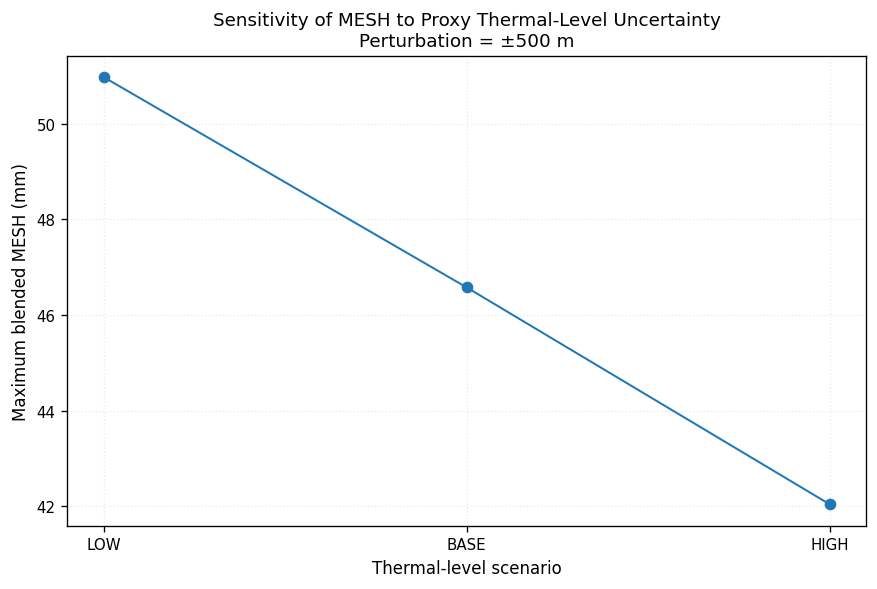

In [35]:
# CELL 35 — Thermal-sensitivity figure

if not THERMAL_SENSITIVITY.empty:

    fig = plt.figure(
        figsize=(
            7.2,
            4.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.plot(
        THERMAL_SENSITIVITY[
            "scenario"
        ],
        THERMAL_SENSITIVITY[
            "maximum_MESH_mm"
        ],
        marker="o",
    )

    ax.set_xlabel(
        "Thermal-level scenario"
    )

    ax.set_ylabel(
        "Maximum blended MESH (mm)"
    )

    ax.set_title(
        (
            "Sensitivity of MESH to Proxy Thermal-Level Uncertainty\n"
            f"Perturbation = ±{THERMAL_PERTURBATION_M:.0f} m"
        )
    )

    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

    F = (
        FIGURE_DIR
        / (
            "08_"
            f"{THERMAL_SOURCE_LABEL}_"
            "thermal_sensitivity_max_MESH.png"
        )
    )

    save_figure(
        fig,
        F,
        product="thermal-level MESH sensitivity",
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
        perturbation_m=(
            THERMAL_PERTURBATION_M
        ),
        units="mm",
    )

    plt.show()

# 27. วิธีอ่าน thermal sensitivity

ถ้า LOW / BASE / HIGH ให้ maximum MESH ใกล้กัน:

```text
retrieval is relatively insensitive
to this ±500 m perturbation
```

ถ้าต่างกันมาก:

```text
thermal-level uncertainty materially affects hail retrieval
```

แต่ห้ามสรุปว่า ±500 m คือ actual uncertainty distribution

หากนำไปทำวิจัยจริง ควรประเมิน uncertainty จาก:

- sounding comparison
- reanalysis spread
- model analysis
- spatial gradients
- temporal evolution

# 28. Export peak hail products เป็น GeoTIFF

จะ export:

```text
SHI
POSH
MESH_witt1998
MESH_mh2019_75
MESH_mh2019_95
MESH_blend
```

ชื่อไฟล์จะติด thermal-source label เช่น:

```text
08_PROXY_OBSERVED_WMO48811_peak_MESH_blend_native_AEQD.tif
```

เพื่อป้องกันไม่ให้ proxy-derived product ถูกสับสนกับ local/reanalysis product ในอนาคต

In [36]:
# CELL 36 — Raster geometry

PYART_SPHERE_RADIUS_M = 6370997.0

NATIVE_AEQD_CRS = (
    rasterio.crs.CRS.from_proj4(
        (
            f"+proj=aeqd "
            f"+lat_0={RADAR_LAT} "
            f"+lon_0={RADAR_LON} "
            f"+R={PYART_SPHERE_RADIUS_M} "
            "+units=m "
            "+no_defs"
        )
    )
)

x_m = (
    STORM_X_KM
    * 1000.0
)

y_m = (
    STORM_Y_KM
    * 1000.0
)

dx_m = (
    STORM_DX_KM
    * 1000.0
)

dy_m = (
    STORM_DY_KM
    * 1000.0
)

west = float(
    x_m.min()
    - dx_m
    / 2.0
)

north = float(
    y_m.max()
    + dy_m
    / 2.0
)

STORM_TRANSFORM = (
    from_origin(
        west,
        north,
        dx_m,
        dy_m,
    )
)

In [37]:
# CELL 37 — Hail GeoTIFF writer

def write_hail_geotiff(
    array_2d,
    *,
    output_path,
    product,
    units,
):
    output_path = Path(
        output_path
    )

    array = np.asarray(
        array_2d,
        dtype=float,
    )

    raster_array = np.flipud(
        np.where(
            np.isfinite(
                array
            ),
            array,
            GEOTIFF_NODATA,
        )
    ).astype(
        "float32"
    )

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=raster_array.shape[
            0
        ],
        width=raster_array.shape[
            1
        ],
        count=1,
        dtype="float32",
        crs=(
            NATIVE_AEQD_CRS
        ),
        transform=(
            STORM_TRANSFORM
        ),
        nodata=(
            GEOTIFF_NODATA
        ),
        compress="deflate",
    ) as dst:

        dst.write(
            raster_array,
            1,
        )

        dst.update_tags(
            event_id=str(
                ACTIVE_EVENT.get(
                    "event_id"
                )
            ),
            source_file=(
                SELECTED_FILENAME
            ),
            product=(
                product
            ),
            units=(
                units
            ),
            radar_band=(
                RADAR_BAND
            ),
            thermal_input_mode=(
                THERMAL_INPUT_MODE
            ),
            thermal_source=(
                THERMAL_SOURCE_LABEL
            ),
            freezing_level_m_MSL=(
                FREEZING_LEVEL_M_MSL
            ),
            minus20_level_m_MSL=(
                MINUS20_LEVEL_M_MSL
            ),
            spatial_proxy=(
                str(
                    THERMAL_INPUT_MODE
                    == "PROXY_SOUNDING"
                )
            ),
            interpretation=(
                "Radar-derived hail retrieval; not observed hail-size truth."
            ),
        )

    return output_path

In [38]:
# CELL 38 — Export peak hail GeoTIFFs

HAIL_GEOTIFF_ROWS = []

products = {
    "SHI": {
        "array": (
            PEAK_SHI
        ),
        "units": (
            "algorithm units"
        ),
    },
    "POSH": {
        "array": (
            PEAK_POSH
        ),
        "units": (
            "percent"
        ),
    },
}

for method in (
    MESH_METHODS
):
    products[
        "MESH_"
        + method
    ] = {
        "array": (
            PEAK_MESH[
                method
            ]
        ),
        "units": (
            "mm"
        ),
    }


for product_name, info in (
    products.items()
):
    path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "08_"
            f"{THERMAL_SOURCE_LABEL}_"
            f"peak_{product_name}_native_AEQD.tif"
        )
    )

    write_hail_geotiff(
        info[
            "array"
        ],
        output_path=(
            path
        ),
        product=(
            product_name
        ),
        units=(
            info[
                "units"
            ]
        ),
    )

    HAIL_GEOTIFF_ROWS.append({
        "product": (
            product_name
        ),
        "units": (
            info[
                "units"
            ]
        ),
        "path": str(
            path
        ),
    })


HAIL_GEOTIFF_MANIFEST = pd.DataFrame(
    HAIL_GEOTIFF_ROWS
)

display(
    HAIL_GEOTIFF_MANIFEST
)

HAIL_GEOTIFF_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "08_hail_GeoTIFF_manifest.csv"
)

HAIL_GEOTIFF_MANIFEST.to_csv(
    HAIL_GEOTIFF_MANIFEST_CSV,
    index=False,
)

,product,units,path
0,SHI,algorithm units,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
1,POSH,percent,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
2,MESH_witt1998,mm,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
3,MESH_mh2019_75,mm,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
4,MESH_mh2019_95,mm,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
5,MESH_blend,mm,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


In [39]:
# CELL 39 — Reopen and validate hail GeoTIFFs

validation_rows = []

for _, row in (
    HAIL_GEOTIFF_MANIFEST.iterrows()
):
    path = Path(
        row[
            "path"
        ]
    )

    with rasterio.open(
        path
    ) as src:
        data = src.read(
            1,
            masked=True,
        )

        validation_rows.append({
            "product": (
                row[
                    "product"
                ]
            ),
            "crs": str(
                src.crs
            ),
            "width": (
                src.width
            ),
            "height": (
                src.height
            ),
            "valid_pixel_count": int(
                data.count()
            ),
            "minimum": (
                float(
                    data.min()
                )
                if data.count()
                else np.nan
            ),
            "maximum": (
                float(
                    data.max()
                )
                if data.count()
                else np.nan
            ),
        })


HAIL_GEOTIFF_VALIDATION = pd.DataFrame(
    validation_rows
)

display(
    HAIL_GEOTIFF_VALIDATION
)

HAIL_GEOTIFF_VALIDATION_CSV = (
    OUTPUT_CSV_DIR
    / "08_hail_GeoTIFF_validation.csv"
)

HAIL_GEOTIFF_VALIDATION.to_csv(
    HAIL_GEOTIFF_VALIDATION_CSV,
    index=False,
)

,product,crs,width,height,valid_pixel_count,minimum,maximum
0,SHI,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,330.831421
1,POSH,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,80.810356
2,MESH_witt1998,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,46.199482
3,MESH_mh2019_75,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,49.877064
4,MESH_mh2019_95,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,75.799721
5,MESH_blend,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,137593,0.0,46.578617


# 29. ตรวจ dual-polarization readiness

ข้อมูล Omkoi มี fields:

```text
corrected_reflectivity
corrected_differential_reflectivity
cross_correlation_ratio
differential_phase
specific_differential_phase
```

แต่:

```text
field exists
≠
field is publication-ready
```

Notebook จึงตรวจ masked fraction และ distribution ก่อนพิจารณา HDR/HSDA/HACC

In [40]:
# CELL 40 — Robust radar reader

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():
            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:
                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:
            raise RuntimeError(
                f"Could not read {path.name}: "
                f"{unpacked_error!r}"
            ) from direct_error

In [41]:
# CELL 41 — Read peak native radar

RADAR_PATH = (
    RADAR_DIR
    / SELECTED_FILENAME
)

peak_radar = read_radar_file(
    RADAR_PATH
)

print(
    "Peak radar:",
    SELECTED_FILENAME,
)

print(
    "Fields:"
)

for field_name in (
    peak_radar.fields
):
    print(
        " -",
        field_name,
    )

Peak radar: 20230318111202.uf.gz
Fields:
 - corrected_reflectivity
 - velocity
 - spectrum_width
 - reflectivity
 - corrected_differential_reflectivity
 - specific_differential_phase
 - differential_phase
 - cross_correlation_ratio


In [42]:
# CELL 42 — Dual-pol field quality summary

DUALPOL_FIELDS = [
    "corrected_reflectivity",
    "corrected_differential_reflectivity",
    "cross_correlation_ratio",
    "differential_phase",
    "specific_differential_phase",
]

dualpol_rows = []

for field_name in (
    DUALPOL_FIELDS
):
    if field_name not in (
        peak_radar.fields
    ):
        dualpol_rows.append({
            "field": (
                field_name
            ),
            "available": False,
            "masked_fraction": np.nan,
            "valid_gate_count": 0,
            "p05": np.nan,
            "median": np.nan,
            "p95": np.nan,
            "minimum": np.nan,
            "maximum": np.nan,
        })

        continue

    data = np.ma.asarray(
        peak_radar.fields[
            field_name
        ][
            "data"
        ]
    )

    mask = np.ma.getmaskarray(
        data
    )

    values = data.compressed()

    dualpol_rows.append({
        "field": (
            field_name
        ),
        "available": True,
        "masked_fraction": float(
            mask.mean()
        ),
        "valid_gate_count": int(
            values.size
        ),
        "p05": (
            float(
                np.nanpercentile(
                    values,
                    5,
                )
            )
            if values.size
            else np.nan
        ),
        "median": (
            float(
                np.nanmedian(
                    values
                )
            )
            if values.size
            else np.nan
        ),
        "p95": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
        "minimum": (
            float(
                np.nanmin(
                    values
                )
            )
            if values.size
            else np.nan
        ),
        "maximum": (
            float(
                np.nanmax(
                    values
                )
            )
            if values.size
            else np.nan
        ),
    })


DUALPOL_QUALITY = pd.DataFrame(
    dualpol_rows
)

display(
    DUALPOL_QUALITY
)

DUALPOL_QUALITY_CSV = (
    OUTPUT_CSV_DIR
    / "08_dualpol_field_quality.csv"
)

DUALPOL_QUALITY.to_csv(
    DUALPOL_QUALITY_CSV,
    index=False,
)

,field,available,masked_fraction,valid_gate_count,p05,median,p95,minimum,maximum
0,corrected_reflectivity,True,0.941684,131464,-11.000,12.000,38.50,-24.000,70.50
1,corrected_differential_reflectivity,True,0.949249,114411,-0.440,0.580,4.83,-7.920,12.00
2,cross_correlation_ratio,True,0.903922,216594,0.405,0.952,1.00,0.003,1.00
3,differential_phase,True,0.966955,74494,0.000,5.660,360.00,0.000,360.00
4,specific_differential_phase,True,0.966955,74494,-0.390,0.000,0.47,-2.100,3.25


# 30. HDR, HSDA และ HACC — readiness ไม่ใช่ execution

### HDR

ใช้ ZH + ZDR เป็นหลัก แต่ ZDR calibration ยังจำเป็น

### HSDA

ต้องมี:

```text
polarimetric QC
HCA hail candidates
thermal levels
```

และ pyhail ปัจจุบันไม่มี full Q-confidence vector implementation

### HACC

เป็น advanced hail-accumulation retrieval และต้องมี environmental assumptions เพิ่ม

ดังนั้น Notebook 08 นี้:

```text
MESH / SHI → run
HDR / HSDA / HACC → readiness assessment
```

In [43]:
# CELL 43 — Hail retrieval readiness table

quality_lookup = (
    DUALPOL_QUALITY.set_index(
        "field"
    )
)


def field_available(
    name,
):
    return bool(
        name in quality_lookup.index
        and quality_lookup.loc[
            name,
            "available"
        ]
    )


def masked_fraction(
    name,
):
    if name not in (
        quality_lookup.index
    ):
        return np.nan

    return float(
        quality_lookup.loc[
            name,
            "masked_fraction"
        ]
    )


HDR_INPUT_READY = (
    field_available(
        "corrected_reflectivity"
    )
    and field_available(
        "corrected_differential_reflectivity"
    )
)

HSDA_BASIC_FIELDS_READY = all(
    field_available(
        name
    )
    for name in [
        "corrected_reflectivity",
        "corrected_differential_reflectivity",
        "cross_correlation_ratio",
    ]
)

KDP_SPARSE = (
    (
        masked_fraction(
            "specific_differential_phase"
        )
        > 0.90
    )
    if np.isfinite(
        masked_fraction(
            "specific_differential_phase"
        )
    )
    else True
)

PHIDP_SPARSE = (
    (
        masked_fraction(
            "differential_phase"
        )
        > 0.90
    )
    if np.isfinite(
        masked_fraction(
            "differential_phase"
        )
    )
    else True
)

HCA_AVAILABLE = any(
    field.lower()
    in [
        "hydrometeor_classification",
        "hydro",
        "hca",
    ]
    for field in (
        peak_radar.fields
    )
)

RETRIEVAL_READINESS = pd.DataFrame([
    {
        "retrieval": "MESH / SHI",
        "recommended_status": "READY",
        "note": (
            "Reflectivity-based 3-D retrieval using documented thermal input."
        ),
    },
    {
        "retrieval": "HDR",
        "recommended_status": (
            "INPUTS PRESENT — QC/CALIBRATION FIRST"
            if HDR_INPUT_READY
            else "NOT READY"
        ),
        "note": (
            "Requires trustworthy ZH and calibrated ZDR."
        ),
    },
    {
        "retrieval": "HSDA",
        "recommended_status": "DEFER",
        "note": (
            "Requires validated HCA hail candidates and polarimetric QC."
        ),
    },
    {
        "retrieval": "HACC",
        "recommended_status": "DEFER",
        "note": (
            "Advanced surface accumulation retrieval with additional assumptions."
        ),
    },
])

display(
    RETRIEVAL_READINESS
)

RETRIEVAL_READINESS_CSV = (
    OUTPUT_CSV_DIR
    / "08_hail_retrieval_readiness.csv"
)

RETRIEVAL_READINESS.to_csv(
    RETRIEVAL_READINESS_CSV,
    index=False,
)

,retrieval,recommended_status,note
0,MESH / SHI,READY,Reflectivity-based 3-D retrieval using documen...
1,HDR,INPUTS PRESENT — QC/CALIBRATION FIRST,Requires trustworthy ZH and calibrated ZDR.
2,HSDA,DEFER,Requires validated HCA hail candidates and pol...
3,HACC,DEFER,Advanced surface accumulation retrieval with a...


# 31. Optional 10-volume MESH lifecycle

Notebook 07 สร้าง severe-core center ของทุก volume แล้ว

Notebook 08 จะ reuse:

```text
07_severe_storm_lifecycle_metrics.csv
```

แล้วสร้าง dynamic 1-km grid สำหรับแต่ละ scan

จากนั้นคำนวณ:

```text
maximum SHI
maximum blended MESH
maximum POSH
area MESH ≥ 20 / 40 / 50 mm
```

ใช้ BASE thermal input เท่านั้น

ถ้าไม่ต้องการใช้เวลารันส่วนนี้ ให้ตั้ง:

```python
RUN_OPTIONAL_MESH_LIFECYCLE = False
```

In [44]:
# CELL 44 — Lifecycle parameters and helpers

LOCAL_TIMEZONE = COURSE_CONFIG[
    "time"
][
    "local_timezone"
]

RADAR_FILES = list(
    COURSE_CONFIG[
        "radar"
    ][
        "source_files"
    ]
)

WEIGHTING_FUNCTION = str(
    grid_config_lookup[
        "weighting_function"
    ]
)

ROI_FUNCTION = str(
    grid_config_lookup[
        "roi_function"
    ]
)

MIN_RADIUS_M = float(
    grid_config_lookup[
        "minimum_roi_m"
    ]
)

ROI_NB = float(
    grid_config_lookup[
        "roi_nb"
    ]
)

ROI_BSP = float(
    grid_config_lookup[
        "roi_bsp"
    ]
)

ROI_H_FACTOR = ast.literal_eval(
    str(
        grid_config_lookup[
            "roi_h_factor"
        ]
    )
)

LIFECYCLE_GRID_DX_KM = 1.0

LIFECYCLE_HALF_WIDTH_KM = 90.0


def radar_datetime_utc(
    radar_object,
):
    units = radar_object.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    dt = num2date(
        radar_object.time[
            "data"
        ][0],
        units=units,
        calendar=radar_object.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    timestamp = pd.Timestamp(
        dt
    )

    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize(
            "UTC"
        )

    else:
        timestamp = timestamp.tz_convert(
            "UTC"
        )

    return timestamp

In [45]:
# CELL 45 — Build storm-centered lifecycle grid

def build_mesh_lifecycle_grid(
    radar_object,
    *,
    center_x_km,
    center_y_km,
):
    gatefilter = (
        pyart.filters.GateFilter(
            radar_object
        )
    )

    gatefilter.exclude_invalid(
        FIELD_Z
    )

    gatefilter.exclude_masked(
        FIELD_Z
    )

    try:
        gatefilter.exclude_transition()
    except Exception:
        pass

    nz = len(
        STORM_Z_KM_MSL
    )

    nx = int(
        round(
            2.0
            * LIFECYCLE_HALF_WIDTH_KM
            / LIFECYCLE_GRID_DX_KM
        )
    ) + 1

    ny = nx

    grid = pyart.map.grid_from_radars(
        (
            radar_object,
        ),
        grid_shape=(
            nz,
            ny,
            nx,
        ),
        grid_limits=(
            (
                STORM_Z_KM_MSL.min()
                * 1000.0,
                STORM_Z_KM_MSL.max()
                * 1000.0,
            ),
            (
                (
                    center_y_km
                    - LIFECYCLE_HALF_WIDTH_KM
                )
                * 1000.0,
                (
                    center_y_km
                    + LIFECYCLE_HALF_WIDTH_KM
                )
                * 1000.0,
            ),
            (
                (
                    center_x_km
                    - LIFECYCLE_HALF_WIDTH_KM
                )
                * 1000.0,
                (
                    center_x_km
                    + LIFECYCLE_HALF_WIDTH_KM
                )
                * 1000.0,
            ),
        ),
        grid_origin=(
            RADAR_LAT,
            RADAR_LON,
        ),
        grid_origin_alt=0.0,
        fields=[
            FIELD_Z
        ],
        gatefilters=(
            gatefilter
        ),
        gridding_algo=(
            "map_gates_to_grid"
        ),
        weighting_function=(
            WEIGHTING_FUNCTION
        ),
        roi_func=(
            ROI_FUNCTION
        ),
        min_radius=(
            MIN_RADIUS_M
        ),
        nb=(
            ROI_NB
        ),
        bsp=(
            ROI_BSP
        ),
        h_factor=(
            ROI_H_FACTOR
        ),
        map_roi=False,
    )

    grid.radar_altitude[
        "data"
    ] = np.array(
        [
            0.0
        ],
        dtype=float,
    )

    return grid

In [46]:
# CELL 46 — Run optional blended-MESH lifecycle

LIFECYCLE_07[
    "time_UTC"
] = pd.to_datetime(
    LIFECYCLE_07[
        "time_UTC"
    ],
    utc=True,
)

lifecycle_lookup = (
    LIFECYCLE_07.set_index(
        "filename"
    )
)

MESH_LIFECYCLE_ROWS = []

if RUN_OPTIONAL_MESH_LIFECYCLE:

    for file_index, filename in enumerate(
        RADAR_FILES,
        start=1,
    ):
        print(
            f"[{file_index:02d}/{len(RADAR_FILES)}] "
            f"{filename}"
        )

        if filename not in (
            lifecycle_lookup.index
        ):
            raise KeyError(
                f"No Notebook 07 storm center for {filename}."
            )

        center_row = (
            lifecycle_lookup.loc[
                filename
            ]
        )

        radar_i = read_radar_file(
            RADAR_DIR
            / filename
        )

        time_utc_i = (
            radar_datetime_utc(
                radar_i
            )
        )

        grid_i = (
            build_mesh_lifecycle_grid(
                radar_i,
                center_x_km=float(
                    center_row[
                        "native_core_center_x_km"
                    ]
                ),
                center_y_km=float(
                    center_row[
                        "native_core_center_y_km"
                    ]
                ),
            )
        )

        start = (
            time.perf_counter()
        )

        run_i = (
            run_mesh_grid_pyhail(
                grid_i,
                field_name=(
                    FIELD_Z
                ),
                temp_levels_m_MSL=(
                    PYHAIL_LEVELS_M_MSL
                ),
                mesh_method=(
                    PRIMARY_MESH_METHOD
                ),
            )
        )

        elapsed = (
            time.perf_counter()
            - start
        )

        _, mesh_field_i = (
            find_hail_output_field(
                run_i,
                [
                    "mesh_"
                    + PRIMARY_MESH_METHOD,
                    "mesh",
                    "MESH",
                ],
            )
        )

        _, shi_field_i = (
            find_hail_output_field(
                run_i,
                [
                    "shi",
                    "SHI",
                ],
            )
        )

        _, posh_field_i = (
            find_hail_output_field(
                run_i,
                [
                    "posh",
                    "POSH",
                ],
            )
        )

        mesh_i = (
            field_dict_to_2d(
                mesh_field_i
            )
        )

        shi_i = (
            field_dict_to_2d(
                shi_field_i
            )
        )

        posh_i = (
            field_dict_to_2d(
                posh_field_i
            )
        )

        pixel_area_lifecycle_km2 = (
            LIFECYCLE_GRID_DX_KM**2
        )

        valid_mesh = np.isfinite(
            mesh_i
        )

        MESH_LIFECYCLE_ROWS.append({
            "filename": (
                filename
            ),
            "time_UTC": (
                time_utc_i
            ),
            "time_ICT": (
                time_utc_i.tz_convert(
                    LOCAL_TIMEZONE
                )
            ),
            "thermal_source": (
                THERMAL_SOURCE_LABEL
            ),
            "freezing_level_m_MSL": (
                FREEZING_LEVEL_M_MSL
            ),
            "minus20_level_m_MSL": (
                MINUS20_LEVEL_M_MSL
            ),
            "mesh_method": (
                PRIMARY_MESH_METHOD
            ),
            "maximum_SHI": (
                float(
                    np.nanmax(
                        shi_i
                    )
                )
                if np.isfinite(
                    shi_i
                ).any()
                else np.nan
            ),
            "maximum_MESH_mm": (
                float(
                    np.nanmax(
                        mesh_i
                    )
                )
                if valid_mesh.any()
                else np.nan
            ),
            "maximum_POSH_percent": (
                float(
                    np.nanmax(
                        posh_i
                    )
                )
                if np.isfinite(
                    posh_i
                ).any()
                else np.nan
            ),
            "area_MESH_ge_20mm_km2": float(
                (
                    valid_mesh
                    & (
                        mesh_i
                        >= 20.0
                    )
                ).sum()
                * pixel_area_lifecycle_km2
            ),
            "area_MESH_ge_40mm_km2": float(
                (
                    valid_mesh
                    & (
                        mesh_i
                        >= 40.0
                    )
                ).sum()
                * pixel_area_lifecycle_km2
            ),
            "area_MESH_ge_50mm_km2": float(
                (
                    valid_mesh
                    & (
                        mesh_i
                        >= 50.0
                    )
                ).sum()
                * pixel_area_lifecycle_km2
            ),
            "pyhail_elapsed_seconds": (
                elapsed
            ),
        })

        del run_i
        del grid_i
        del radar_i

        gc.collect()

else:
    print(
        "Optional MESH lifecycle disabled."
    )


MESH_LIFECYCLE = pd.DataFrame(
    MESH_LIFECYCLE_ROWS
)

if not MESH_LIFECYCLE.empty:
    display(
        MESH_LIFECYCLE
    )


MESH_LIFECYCLE_CSV = (
    OUTPUT_CSV_DIR
    / "08_MESH_lifecycle.csv"
)

MESH_LIFECYCLE.to_csv(
    MESH_LIFECYCLE_CSV,
    index=False,
)

[01/10] 20230318110609.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[02/10] 20230318111202.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[03/10] 20230318111802.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[04/10] 20230318112402.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[05/10] 20230318113002.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[06/10] 20230318113602.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[07/10] 20230318114202.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[08/10] 20230318114802.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[09/10] 20230318115402.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)
[10/10] 20230318120002.uf.gz
pyhail input grid: (nz, ny, nx) = (38, 181, 181)


,filename,time_UTC,time_ICT,thermal_source,freezing_level_m_MSL,minus20_level_m_MSL,mesh_method,maximum_SHI,maximum_MESH_mm,maximum_POSH_percent,area_MESH_ge_20mm_km2,area_MESH_ge_40mm_km2,area_MESH_ge_50mm_km2,pyhail_elapsed_seconds
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,235.227091,39.060818,70.919686,33.0,0.0,0.0,0.285424
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,321.846517,45.915013,80.011865,37.0,4.0,0.0,0.278313
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,204.637765,36.398183,66.879697,25.0,0.0,0.0,0.414479
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,137.050738,29.754708,55.253881,19.0,0.0,0.0,0.277142
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,70.835288,21.383248,36.114057,1.0,0.0,0.0,0.294977
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,63.260215,20.207126,32.834138,1.0,0.0,0.0,0.389622
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,34.468918,14.915199,15.225378,0.0,0.0,0.0,0.298332
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,24.558016,12.589516,5.393807,0.0,0.0,0.0,0.277401
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,102.035702,25.667389,46.698056,7.0,0.0,0.0,0.299534
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,PROXY_OBSERVED_WMO48811,4092.882353,7658.0,blend,89.774200,24.074398,42.985327,5.0,0.0,0.0,0.293955


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/08/08_PROXY_OBSERVED_WMO48811_MESH_lifecycle.png


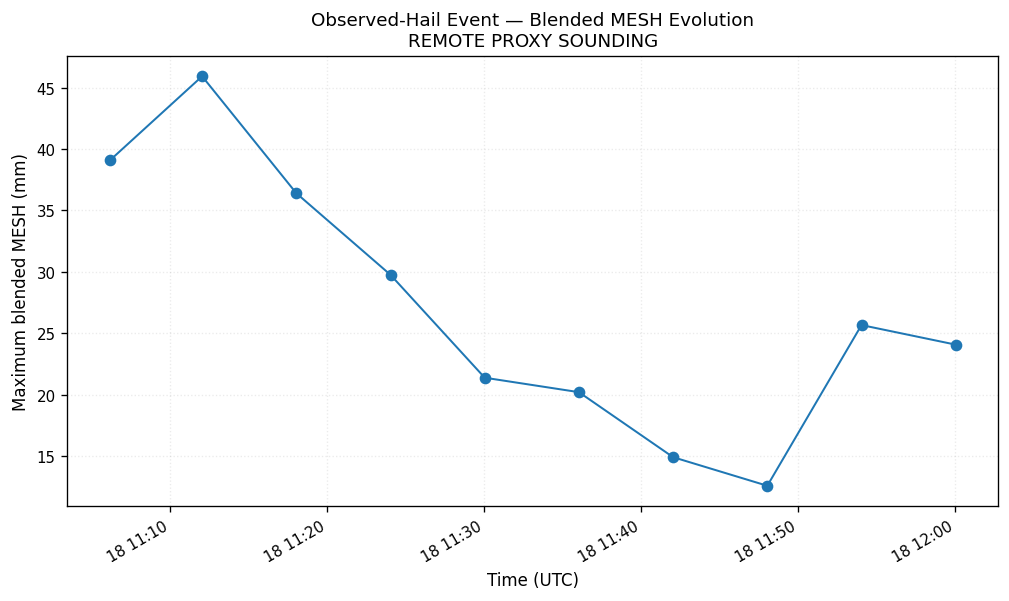

In [47]:
# CELL 47 — MESH lifecycle figure

if not MESH_LIFECYCLE.empty:

    fig = plt.figure(
        figsize=(
            8.3,
            4.9,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.plot(
        MESH_LIFECYCLE[
            "time_UTC"
        ],
        MESH_LIFECYCLE[
            "maximum_MESH_mm"
        ],
        marker="o",
    )

    ax.set_xlabel(
        "Time (UTC)"
    )

    ax.set_ylabel(
        "Maximum blended MESH (mm)"
    )

    ax.set_title(
        (
            "Observed-Hail Event — Blended MESH Evolution\n"
            f"{title_prefix}"
        )
    )

    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

    fig.autofmt_xdate()

    F = (
        FIGURE_DIR
        / (
            "08_"
            f"{THERMAL_SOURCE_LABEL}_"
            "MESH_lifecycle.png"
        )
    )

    save_figure(
        fig,
        F,
        product="MESH lifecycle",
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
        mesh_method=(
            PRIMARY_MESH_METHOD
        ),
        units="mm",
    )

    plt.show()

# 32. เปรียบเทียบ MESH กับ severe metrics จาก Notebook 07

เมื่อ optional lifecycle พร้อม จะ merge:

```text
maximum ZH
ET40
ET50
VIL56
VILD18
50-dBZ echo volume
MESH
```

เพื่อให้นิสิตเห็นว่า hail-specific retrieval และ severe-core metrics ไม่ได้ peak พร้อมกันเสมอ

In [48]:
# CELL 48 — Merge MESH lifecycle with Notebook 07 severe metrics

MERGED_HAIL_SEVERE_LIFECYCLE = pd.DataFrame()

if not MESH_LIFECYCLE.empty:

    mesh_for_merge = (
        MESH_LIFECYCLE.copy()
    )

    mesh_for_merge[
        "time_UTC"
    ] = pd.to_datetime(
        mesh_for_merge[
            "time_UTC"
        ],
        utc=True,
    )

    severe_for_merge = (
        LIFECYCLE_07.copy()
    )

    severe_for_merge[
        "time_UTC"
    ] = pd.to_datetime(
        severe_for_merge[
            "time_UTC"
        ],
        utc=True,
    )

    MERGED_HAIL_SEVERE_LIFECYCLE = (
        severe_for_merge.merge(
            mesh_for_merge[
                [
                    "filename",
                    "maximum_SHI",
                    "maximum_MESH_mm",
                    "maximum_POSH_percent",
                    "area_MESH_ge_20mm_km2",
                    "area_MESH_ge_40mm_km2",
                    "area_MESH_ge_50mm_km2",
                ]
            ],
            on="filename",
            how="inner",
        )
    )

    display(
        MERGED_HAIL_SEVERE_LIFECYCLE[
            [
                "filename",
                "time_UTC",
                "maximum_ZH_dBZ",
                "maximum_ET40_km_MSL",
                "maximum_ET50_km_MSL",
                "maximum_VIL56_kg_m2",
                "maximum_MESH_mm",
            ]
        ]
    )


MERGED_LIFECYCLE_CSV = (
    OUTPUT_CSV_DIR
    / "08_MESH_vs_severe_metrics_lifecycle.csv"
)

MERGED_HAIL_SEVERE_LIFECYCLE.to_csv(
    MERGED_LIFECYCLE_CSV,
    index=False,
)

,filename,time_UTC,maximum_ZH_dBZ,maximum_ET40_km_MSL,maximum_ET50_km_MSL,maximum_VIL56_kg_m2,maximum_MESH_mm
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,62.715824,11.389129,9.319166,36.108621,39.060818
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,57.486195,11.815581,9.659167,40.245372,45.915013
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,60.348408,11.141554,7.351337,33.083617,36.398183
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,61.605717,10.390952,8.834447,37.422540,29.754708
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,57.986076,10.378588,9.174979,34.937959,21.383248
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,62.771744,9.431610,7.007449,28.077171,20.207126
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,60.999996,10.063929,7.454358,29.665576,14.915199
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,58.018002,8.968264,7.479322,28.809731,12.589516
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,62.783833,10.573615,9.028258,39.418396,25.667389
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,61.181274,10.634607,8.399517,38.939225,24.074398


# 33. การตีความอย่างมีข้อจำกัด

สำหรับกรณีนี้ เรามีข้อมูลสามชนิดที่บทบาทต่างกัน:

```text
Observed hail event status
→ confirms event-level hail occurrence

Omkoi radar
→ storm structure and radar retrievals

Dien Bien Phu sounding
→ remote environmental proxy
```

จึงควรเขียนผลลัพธ์ในรูป:

> Radar-derived MESH reached ... mm using the Dien Bien Phu remote proxy sounding.

ไม่ควรเขียน:

> The observed hail size was ... mm.

หากไม่มี hailstone-size observation จริง

# 34. แนวทางเขียน Methods

Methods ควรรายงานอย่างน้อย:

1. pyhail version
2. radar site และ band
3. corrected-reflectivity field
4. 3-D grid geometry
5. grid vertical reference
6. sounding station และ WMO number
7. sounding latitude / longitude
8. sounding profile timestamp
9. nominal sounding time
10. distance sounding→radar
11. distance sounding→storm reference
12. temporal offset
13. isotherm interpolation method
14. 0°C level
15. −20°C level
16. MESH formulations
17. near-radar mask
18. C-band correction status
19. thermal-sensitivity experiment
20. statement that proxy sounding is not a local storm observation
21. statement that MESH is not observed hail size

ตัวอย่าง:

> Environmental thermal levels were derived from the 00 UTC 18 March 2023 upper-air sounding at Dien Bien Phu, Vietnam (WMO 48811), which was used as a remote environmental proxy because a contemporaneous local sounding was unavailable near the Omkoi radar. Heights of the 0, −10, −20 and −30°C isotherms were obtained by linear interpolation of the observed temperature–geopotential-height profile. The spatial and temporal offsets between the sounding, radar and storm-reference location were explicitly quantified. SHI, POSH and MESH were then calculated using pyhail v3.4.2 from the storm-focused three-dimensional corrected-reflectivity grid. Four MESH formulations were compared, and an additional ±500 m perturbation of the 0 and −20°C levels was evaluated as a teaching sensitivity experiment. Retrieved MESH values were interpreted as radar-derived estimates rather than observed hail diameters.

# 35. CORE — แบบฝึกหัด

### แบบฝึกหัด 1 — Derive isotherms

จาก `08_thermal_isotherm_levels.csv`

ตอบ:

- 0°C level เท่าใด?
- −20°C level เท่าใด?
- ระดับใดได้จาก exact profile level?
- ระดับใดได้จาก interpolation?

### แบบฝึกหัด 2 — Representativeness

จาก `08_thermal_input_provenance.csv`

ตอบ:

- sounding ห่าง radar กี่ km?
- sounding ห่าง storm reference กี่ km?
- sounding ก่อน radar peak กี่ชั่วโมง?

### แบบฝึกหัด 3 — MESH formulations

เปรียบเทียบ maximum MESH จากทั้ง 4 formulations

### แบบฝึกหัด 4 — Algorithm vs observation

อธิบายความต่างระหว่าง:

```text
Observed-hail event
MESH estimate
Observed hail diameter
```

# 36. ADVANCED / MSc — แบบฝึกหัด

### แบบฝึกหัด 5 — Proxy uncertainty

ใช้:

`08_proxy_thermal_level_sensitivity.csv`

ดูว่า ±500 m ทำให้:

```text
Max SHI
Max MESH
Area MESH ≥ 40 mm
```

เปลี่ยนมากน้อยเพียงใด

### แบบฝึกหัด 6 — Compare environment sources

ถ้าภายหลังมี ERA5 storm-local profile:

```text
Dien Bien Phu proxy
vs
ERA5 storm-local
```

เปรียบเทียบ 0 และ −20°C levels รวมถึง MESH

### แบบฝึกหัด 7 — Lifecycle

เปรียบเทียบ peak time ของ:

```text
ET50
VIL56
MESH
50-dBZ echo volume
```

### แบบฝึกหัด 8 — Dual-pol readiness

อธิบายว่าเหตุใด:

```text
ZDR exists
```

จึงยังไม่เพียงพอสำหรับ publication-grade HDR/HSDA

# 37. RESEARCH NOTE — ลำดับความน่าเชื่อถือของ thermal input

สำหรับงานวิจัย ผมแนะนำลำดับ:

```text
1. Local event-time sounding
2. Storm-local reanalysis / model analysis
3. Remote observed sounding proxy
4. Simulated teaching profile
```

Dien Bien Phu อยู่ในระดับ 3

ดังนั้นสามารถใช้เพื่อ:

- teaching
- exploratory analysis
- sensitivity analysis
- preliminary event study

แต่ publication interpretation ต้องระบุ spatial/temporal limitation อย่างชัดเจน

# 38. Event context และ references

### Event context

สถานะ `observed_hail` ถูกสืบทอดจาก Notebook 01

TMD Monthly Weather Summary for March 2023 สามารถใช้เป็น **regional/event context** เพิ่มเติมได้:

```text
https://www.tmd.go.th/en/climate/summarymonthly/032023
```

แต่ monthly surface-temperature summary ไม่ถูกใช้ derive 0 หรือ −20°C levels ใน Notebook นี้

### Hail retrieval references

Witt, A., Eilts, M. D., Stumpf, G. J., Johnson, J. T., Mitchell, E. D. W., & Thomas, K. W. (1998). An enhanced hail detection algorithm for the WSR-88D. *Weather and Forecasting, 13*(2), 286–303.

Murillo, E. M., & Homeyer, C. R. (2021). Severe hail fall and hailstorm detection using remote sensing observations. *Journal of Applied Meteorology and Climatology*.

### Software

pyhail — Python Hail Retrieval Toolkit  
Pinned version in this notebook: **3.4.2**

```text
https://github.com/joshua-wx/pyhail
```

> Algorithm calibration from other regions must not be treated as a validated Thailand hail-size calibration.

# 39. Export processing metadata

In [49]:
# CELL 49 — Processing metadata

proxy_mode = (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
)

optional_lifecycle_completed = (
    len(
        MESH_LIFECYCLE
    )
    == len(
        RADAR_FILES
    )
    if RUN_OPTIONAL_MESH_LIFECYCLE
    else False
)

metadata_rows = [
    ("event_id", ACTIVE_EVENT.get("event_id")),
    ("event_type", ACTIVE_EVENT.get("event_type")),
    ("radar_site", "Omkoi"),
    ("radar_band", RADAR_BAND),
    ("peak_source_file", SELECTED_FILENAME),
    ("peak_grid_file", str(STORM_GRID_NETCDF)),
    ("reflectivity_field", FIELD_Z),
    (
        "pyhail_version",
        getattr(
            pyhail,
            "__version__",
            "unknown",
        ),
    ),
    ("thermal_input_mode", THERMAL_INPUT_MODE),
    ("thermal_source_label", THERMAL_SOURCE_LABEL),
    (
        "thermal_source_description",
        THERMAL_SOURCE_DESCRIPTION,
    ),
    ("thermal_observed", THERMAL_OBSERVED),
    (
        "local_environment_observation",
        LOCAL_ENVIRONMENT_OBSERVATION,
    ),
    (
        "proxy_station_name",
        PROXY_STATION_NAME
        if proxy_mode
        else "",
    ),
    (
        "proxy_station_WMO",
        PROXY_STATION_WMO
        if proxy_mode
        else "",
    ),
    (
        "proxy_station_latitude_deg",
        PROXY_STATION_LAT
        if proxy_mode
        else np.nan,
    ),
    (
        "proxy_station_longitude_deg",
        PROXY_STATION_LON
        if proxy_mode
        else np.nan,
    ),
    (
        "proxy_profile_time_UTC",
        str(
            SOUNDING_PROFILE_TIME_UTC
        )
        if proxy_mode
        else "",
    ),
    (
        "proxy_nominal_time_UTC",
        str(
            PROXY_NOMINAL_TIME_UTC
        )
        if proxy_mode
        else "",
    ),
    (
        "proxy_distance_to_radar_km",
        DISTANCE_PROXY_TO_RADAR_KM,
    ),
    (
        "proxy_distance_to_storm_reference_km",
        DISTANCE_PROXY_TO_STORM_KM,
    ),
    (
        "proxy_profile_to_peak_offset_hours",
        PROFILE_TO_PEAK_OFFSET_H,
    ),
    (
        "freezing_level_m_MSL",
        FREEZING_LEVEL_M_MSL,
    ),
    (
        "minus10_level_m_MSL",
        MINUS10_LEVEL_M_MSL,
    ),
    (
        "minus20_level_m_MSL",
        MINUS20_LEVEL_M_MSL,
    ),
    (
        "minus30_level_m_MSL",
        MINUS30_LEVEL_M_MSL,
    ),
    (
        "isotherm_method",
        (
            "linear temperature-height interpolation; "
            "exact level retained when present"
        ),
    ),
    (
        "MESH_methods",
        str(
            MESH_METHODS
        ),
    ),
    (
        "primary_MESH_method",
        PRIMARY_MESH_METHOD,
    ),
    (
        "speckle_filter",
        PYHAIL_SPECKLE_FILTER,
    ),
    (
        "near_radar_mask_m",
        PYHAIL_NEAR_RADAR_MASK_M,
    ),
    (
        "transition_width",
        PYHAIL_TRANSITION_WIDTH,
    ),
    (
        "C_band_correction_applied",
        False,
    ),
    (
        "thermal_sensitivity_run",
        RUN_THERMAL_LEVEL_SENSITIVITY,
    ),
    (
        "thermal_sensitivity_perturbation_m",
        THERMAL_PERTURBATION_M,
    ),
    (
        "local_MESH_calibration_applied",
        False,
    ),
    (
        "POSH_locally_calibrated",
        False,
    ),
    (
        "optional_MESH_lifecycle_requested",
        RUN_OPTIONAL_MESH_LIFECYCLE,
    ),
    (
        "optional_MESH_lifecycle_completed",
        optional_lifecycle_completed,
    ),
    (
        "HDR_input_ready",
        HDR_INPUT_READY,
    ),
    (
        "HSDA_basic_fields_ready",
        HSDA_BASIC_FIELDS_READY,
    ),
    (
        "HCA_available",
        HCA_AVAILABLE,
    ),
    (
        "PhiDP_sparse",
        PHIDP_SPARSE,
    ),
    (
        "KDP_sparse",
        KDP_SPARSE,
    ),
    (
        "publication_use_requires_explicit_proxy_limitation",
        proxy_mode,
    ),
    (
        "interpretation",
        (
            "Radar-derived hail diagnostics for an independently known "
            "observed-hail event. The default environmental input is a "
            "remote observed sounding proxy. MESH is not observed hail size "
            "and POSH is not a Thailand-calibrated probability."
        ),
    ),
]

PROCESSING_METADATA = pd.DataFrame(
    metadata_rows,
    columns=[
        "parameter",
        "value",
    ],
)

display(
    PROCESSING_METADATA
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "08_processing_metadata.csv"
)

PROCESSING_METADATA.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,radar_site,Omkoi
3,radar_band,S
4,peak_source_file,20230318111202.uf.gz
5,peak_grid_file,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
6,reflectivity_field,corrected_reflectivity
7,pyhail_version,unknown
8,thermal_input_mode,PROXY_SOUNDING
9,thermal_source_label,PROXY_OBSERVED_WMO48811


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/08_processing_metadata.csv


# 40. Export figure manifest

In [50]:
# CELL 50 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "08_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure_name,figure_path,product,station,wmo,thermal_input_mode,units,dpi,thermal_source,mesh_method,perturbation_m
0,08_fig01_proxy_sounding_temperature_profile.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,proxy sounding temperature profile,Dien Bien Phu,48811,PROXY_SOUNDING,degree C and km MSL,300,NaN,NaN,NaN
1,08_PROXY_OBSERVED_WMO48811_peak_SHI.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,SHI,NaN,NaN,NaN,algorithm units,300,PROXY_OBSERVED_WMO48811,NaN,NaN
2,08_PROXY_OBSERVED_WMO48811_peak_MESH_witt1998.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,witt1998,NaN
3,08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_75...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,mh2019_75,NaN
4,08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_95...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,mh2019_95,NaN
5,08_PROXY_OBSERVED_WMO48811_peak_MESH_blend.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,blend,NaN
6,08_PROXY_OBSERVED_WMO48811_peak_POSH.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,POSH,NaN,NaN,NaN,percent,300,PROXY_OBSERVED_WMO48811,NaN,NaN
7,08_PROXY_OBSERVED_WMO48811_MESH_formulation_se...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH formulation sensitivity,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,NaN,NaN
8,08_PROXY_OBSERVED_WMO48811_thermal_sensitivity...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,thermal-level MESH sensitivity,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,NaN,500.0
9,08_PROXY_OBSERVED_WMO48811_MESH_lifecycle.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH lifecycle,NaN,NaN,NaN,mm,300,PROXY_OBSERVED_WMO48811,blend,NaN


# 41. Output inventory

In [51]:
# CELL 51 — Output inventory

EXPECTED_OUTPUTS = [
    PYHAIL_API_CSV,
    SOUNDING_QC_CSV,
    ISOTHERM_TABLE_CSV,
    THERMAL_PROVENANCE_CSV,
    PYHAIL_OUTPUT_INVENTORY_CSV,
    PEAK_MESH_SENSITIVITY_CSV,
    THERMAL_SENSITIVITY_CSV,
    HAIL_GEOTIFF_MANIFEST_CSV,
    HAIL_GEOTIFF_VALIDATION_CSV,
    DUALPOL_QUALITY_CSV,
    RETRIEVAL_READINESS_CSV,
    MESH_LIFECYCLE_CSV,
    MERGED_LIFECYCLE_CSV,
    PROCESSING_METADATA_CSV,
    FIGURE_MANIFEST_CSV,
]

OUTPUT_INVENTORY = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    OUTPUT_INVENTORY
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 42. Final readiness

Readiness แยกตาม thermal mode

### PROXY_SOUNDING

ถ้าทุกขั้นผ่าน:

```text
NOTEBOOK 08 PROXY-SOUNDING SHI/MESH PIPELINE READY
```

ไม่ได้หมายความว่า local environment ถูกสังเกตโดยตรง

### SIMULATED

ถ้าทุกขั้นผ่าน:

```text
NOTEBOOK 08 TEACHING-SIMULATION SHI/MESH PIPELINE READY
```

ผลทั้งหมดต้องตีความเป็น teaching experiment

### MANUAL

ต้องมี documented source

In [52]:
# CELL 52 — Notebook 08 readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 03 readiness",
    bool(
        (
            readiness_03[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Notebook 07 readiness",
    bool(
        (
            readiness_07[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Radar band is S",
    RADAR_BAND
    == "S",
)

add_check(
    "pyhail mesh_grid.main available",
    getattr(
        mesh_grid,
        "main",
        None,
    )
    is not None,
)

add_check(
    "Thermal mode valid",
    THERMAL_INPUT_MODE
    in ALLOWED_THERMAL_MODES,
)

if (
    THERMAL_INPUT_MODE
    == "PROXY_SOUNDING"
):
    add_check(
        "Proxy sounding file available",
        proxy_path.exists(),
    )

    add_check(
        "Proxy sounding QC contains no FAIL",
        not (
            SOUNDING_QC[
                "status"
            ]
            == "FAIL"
        ).any(),
    )

    add_check(
        "Proxy provenance exported",
        THERMAL_PROVENANCE_CSV.exists(),
        (
            f"{DISTANCE_PROXY_TO_RADAR_KM:.1f} km to radar; "
            f"{PROFILE_TO_PEAK_OFFSET_H:.2f} h to peak"
        ),
    )

add_check(
    "Thermal levels vertically ordered",
    bool(
        FREEZING_LEVEL_M_MSL
        < MINUS10_LEVEL_M_MSL
        < MINUS20_LEVEL_M_MSL
        < MINUS30_LEVEL_M_MSL
    ),
)

add_check(
    "Peak 3-D grid readable",
    storm_grid is not None,
)

add_check(
    "Corrected reflectivity available",
    FIELD_Z
    in storm_grid.fields,
)

add_check(
    "SHI calculated",
    bool(
        np.isfinite(
            PEAK_SHI
        ).any()
    ),
)

add_check(
    "Four MESH formulations calculated",
    len(
        PEAK_MESH
    )
    == len(
        MESH_METHODS
    ),
)

add_check(
    "POSH calculated",
    bool(
        np.isfinite(
            PEAK_POSH
        ).any()
    ),
)

add_check(
    "Thermal sensitivity completed",
    (
        (
            not RUN_THERMAL_LEVEL_SENSITIVITY
        )
        or (
            len(
                THERMAL_SENSITIVITY
            )
            == 3
        )
    ),
)

add_check(
    "Hail GeoTIFFs exported",
    bool(
        len(
            HAIL_GEOTIFF_MANIFEST
        )
        == 6
        and all(
            Path(
                path
            ).exists()
            for path in (
                HAIL_GEOTIFF_MANIFEST[
                    "path"
                ]
            )
        )
    ),
)

add_check(
    "Dual-pol quality inventory exported",
    DUALPOL_QUALITY_CSV.exists(),
)

add_check(
    "Optional MESH lifecycle completed when requested",
    (
        (
            not RUN_OPTIONAL_MESH_LIFECYCLE
        )
        or (
            len(
                MESH_LIFECYCLE
            )
            == len(
                RADAR_FILES
            )
        )
    ),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


READINESS_08 = pd.DataFrame(
    checks
)

display(
    READINESS_08
)

NOTEBOOK_08_READY = bool(
    (
        READINESS_08[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_readiness_check.csv"
)

READINESS_08.to_csv(
    READINESS_08_CSV,
    index=False,
)

print()

if NOTEBOOK_08_READY:

    if (
        THERMAL_INPUT_MODE
        == "PROXY_SOUNDING"
    ):
        print(
            "NOTEBOOK 08 PROXY-SOUNDING SHI/MESH PIPELINE READY"
        )

        print(
            "Remote observed sounding used as environmental proxy."
        )

        print(
            "Interpret MESH with explicit spatial and temporal representativeness limitations."
        )

    elif (
        THERMAL_INPUT_MODE
        == "SIMULATED"
    ):
        print(
            "NOTEBOOK 08 TEACHING-SIMULATION SHI/MESH PIPELINE READY"
        )

    else:
        print(
            "NOTEBOOK 08 DOCUMENTED-MANUAL SHI/MESH PIPELINE READY"
        )

else:
    print(
        "NOTEBOOK 08 REQUIRES REVIEW"
    )

,item,status,note
0,Notebook 03 readiness,PASS,
1,Notebook 07 readiness,PASS,
2,Active event is observed hail,PASS,
3,Radar band is S,PASS,
4,pyhail mesh_grid.main available,PASS,
5,Thermal mode valid,PASS,
6,Proxy sounding file available,PASS,
7,Proxy sounding QC contains no FAIL,PASS,
8,Proxy provenance exported,PASS,621.8 km to radar; 11.45 h to peak
9,Thermal levels vertically ordered,PASS,



NOTEBOOK 08 PROXY-SOUNDING SHI/MESH PIPELINE READY
Remote observed sounding used as environmental proxy.
Interpret MESH with explicit spatial and temporal representativeness limitations.


# ข้อความสำคัญที่ต้องจำ

1. **MESH ไม่ใช่ observed hail diameter**
2. Dien Bien Phu เป็น observed sounding จริง แต่เป็น remote proxy
3. Remote observation ไม่เท่ากับ local storm observation
4. ต้องรายงาน spatial distance และ temporal offset
5. 0°C และ −20°C levels ถูก derive จาก temperature profile ไม่ใช่ monthly surface temperature
6. 0 / −10 / −20 / −30°C levels ใช้ height MSL
7. pyhail input ใช้ 0 และ −20°C levels
8. MESH formulation เปลี่ยนผลลัพธ์ได้
9. ±500 m experiment เป็น sensitivity test ไม่ใช่ estimated true error distribution
10. POSH ไม่ใช่ Thailand-calibrated probability
11. Omkoi เป็น S-band จึงไม่ใช้ C-band correction
12. Grid vertical reference ต้องถูกตรวจเพื่อไม่ให้ radar altitude ถูกบวกซ้ำ
13. Event-level observed hail ไม่ใช่ pixel-level hail truth
14. Field availability ไม่เท่ากับ dual-pol quality
15. HDR ต้องมี ZDR calibration ที่เหมาะสม
16. HSDA ต้องมี HCA hail candidates และ polarimetric QC
17. PhiDP/KDP sparse coverage เป็นเหตุผลให้ defer HSDA
18. MESH lifecycle อาจ peak คนละเวลากับ ET50/VIL
19. Local/reanalysis profile ในอนาคตสามารถแทน proxy mode ได้โดยไม่เปลี่ยน hail-analysis logic
20. ทุก output เก็บ thermal provenance เพื่อ reproducibility

# Expected outputs

```text
event-specific 03_output/csv/
├── 08_pyhail_API_inventory.csv
├── 08_proxy_sounding_QC.csv
├── 08_thermal_isotherm_levels.csv
├── 08_thermal_input_provenance.csv
├── 08_pyhail_peak_output_inventory.csv
├── 08_peak_MESH_formulation_sensitivity.csv
├── 08_proxy_thermal_level_sensitivity.csv
├── 08_hail_GeoTIFF_manifest.csv
├── 08_hail_GeoTIFF_validation.csv
├── 08_dualpol_field_quality.csv
├── 08_hail_retrieval_readiness.csv
├── 08_MESH_lifecycle.csv
├── 08_MESH_vs_severe_metrics_lifecycle.csv
├── 08_processing_metadata.csv
├── 08_figure_manifest.csv
└── 08_readiness_check.csv
```

```text
event-specific 03_output/geotiff/
├── 08_PROXY_OBSERVED_WMO48811_peak_SHI_native_AEQD.tif
├── 08_PROXY_OBSERVED_WMO48811_peak_POSH_native_AEQD.tif
├── 08_PROXY_OBSERVED_WMO48811_peak_MESH_witt1998_native_AEQD.tif
├── 08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_75_native_AEQD.tif
├── 08_PROXY_OBSERVED_WMO48811_peak_MESH_mh2019_95_native_AEQD.tif
└── 08_PROXY_OBSERVED_WMO48811_peak_MESH_blend_native_AEQD.tif
```

เมื่อ default proxy workflow ผ่าน:

```text
NOTEBOOK 08 PROXY-SOUNDING SHI/MESH PIPELINE READY
```